# Paper plots — question-driven evidence

Locked config: `kl-diag-polar-lora` · PolarExpress PE=8 · Nesterov · β₁=0.9 · δ=1e-4 · k=1 · curvature_beta=0.99 · precond_refresh_every=10 · **precond_method=gram_ns**. AdamW, iMuon, Muon, and LoRA-RITE baselines are shown wherever reviewed evidence exists; σ=0.0017 noise floor.

In-flight runs render partially (`allow_partial=True`).

In [66]:
%load_ext autoreload
%autoreload 2

# Keep one module generation for the lifetime of the notebook kernel. Restart
# the kernel after editing plotting code so cached records and their classes
# cannot come from different imports.
import lora_playground.plotting.paper_plots_lib as P
from lora_playground.plotting.style import apply_notebook_style

apply_notebook_style()

# Every figure in one render sees the same log-tree state. Rerunning this setup
# cell refreshes the snapshot deliberately after new sweep results arrive.
P.begin_notebook_snapshot(refresh=True)

# Temporary compatibility imports for the remaining custom analysis cells.
# New and standard figure cells must call P.<entrypoint> directly.
from lora_playground.plotting.paper_plots_lib import (
    ROOT, SIGMA, ADAMW, PROTO, cell_runs,
    om as _om, pred_matches as _pred_matches, variant_key_fn as _variant_key_fn,
)
from lora_playground.plotting import compare_variants_figure


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1 — Does PoLoRA improve optimization across workloads and ranks?

### Code and out-of-distribution workload breadth

#### Figure 1. OLMo-2-1B · OPC · r=256

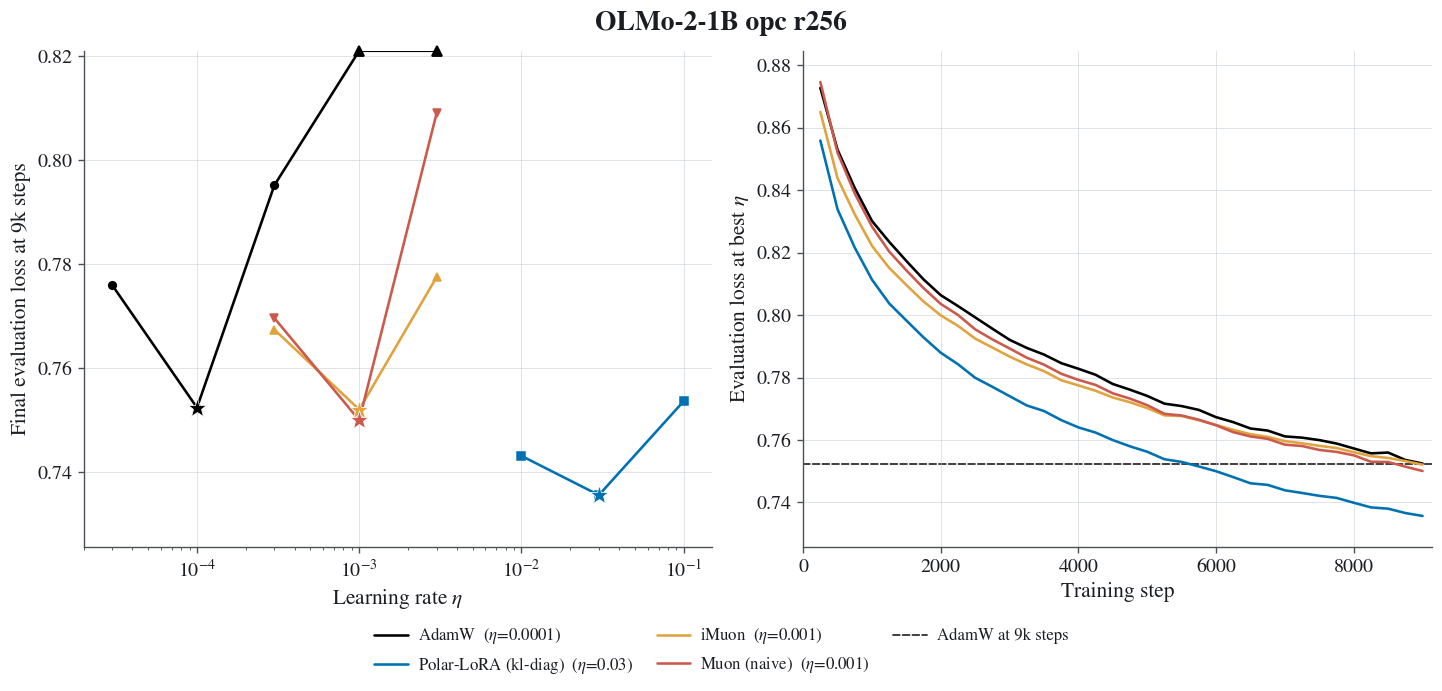

speedup vs AdamW (target 0.7524, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.03   0.7356     1.61x    1.26x  3
  Muon (naive)              0.001   0.7500     1.05x    1.02x  3
  iMuon                     0.001   0.7521     1.01x    1.00x  3
  AdamW                    0.0001   0.7524     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.752439,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0300,0.735641,-0.016797,-9.880739,1
2,iMuon,0.0010,0.752073,-0.000365,-0.214891,1
3,Muon (naive),0.0010,0.750033,-0.002406,-1.415284,1


In [67]:
P.panel_n(0)   # OLMo-2-1B opc r256


#### Figure 2. Qwen2.5-1.5B · OPC · r=256

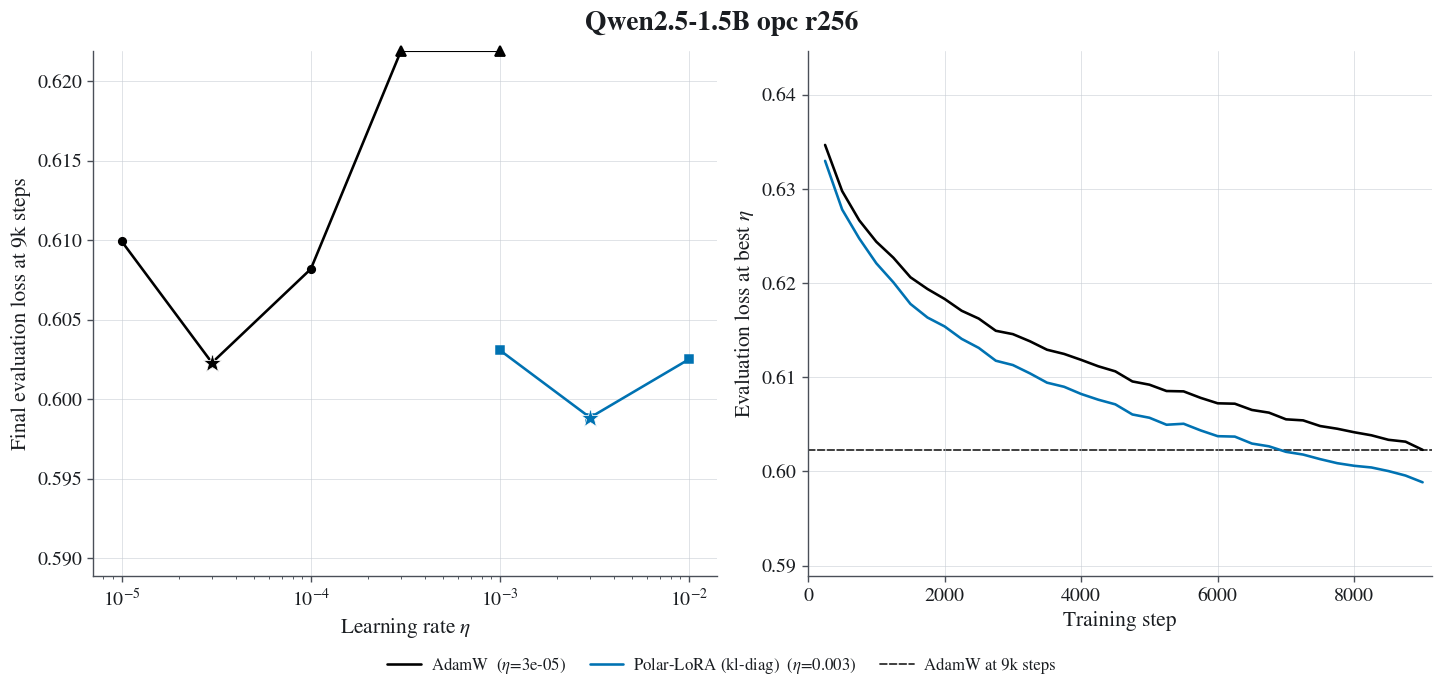

speedup vs AdamW (target 0.6023, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.003   0.5988     1.30x    1.08x  3
  AdamW                     3e-05   0.6023     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.602292,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00300,0.598845,-0.003447,-2.027497,1


In [68]:
P.panel_n(1)   # Qwen2.5-1.5B opc r256


#### Figure 3. Llama-3.2-1B · OPC · r=256

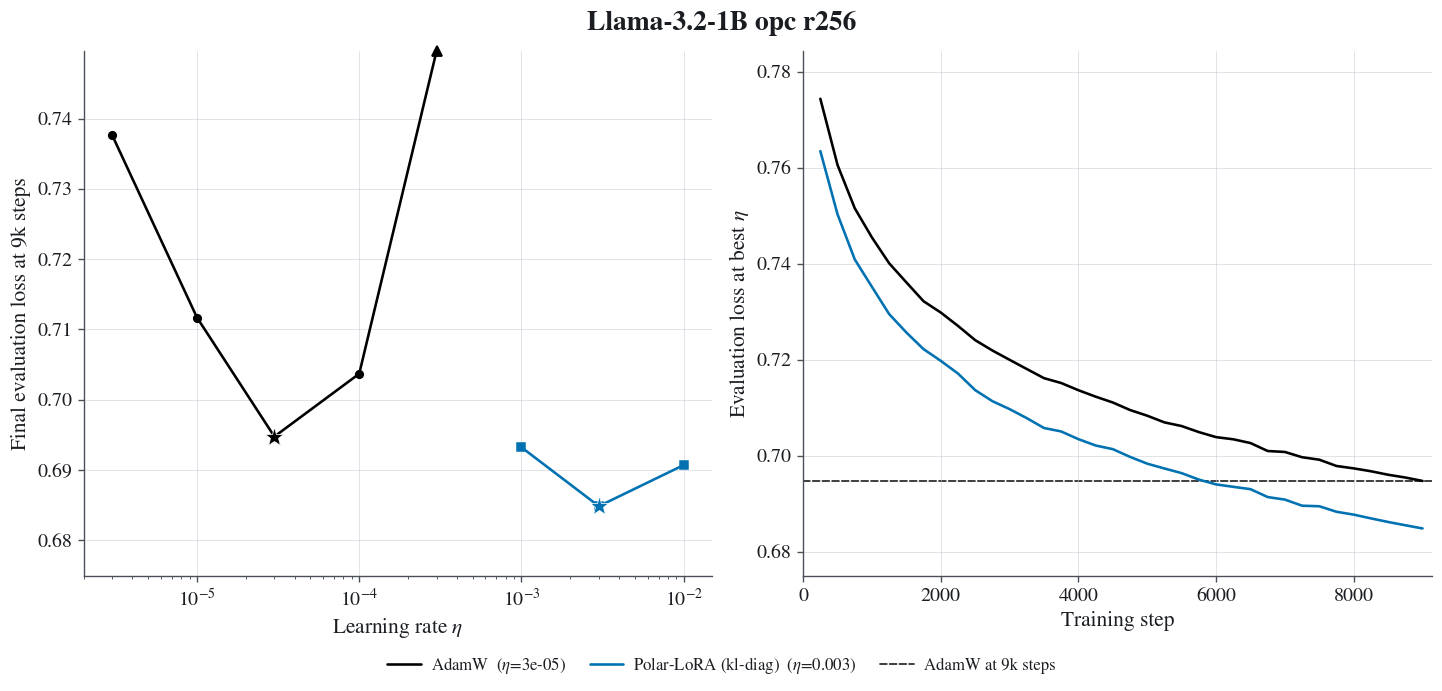

speedup vs AdamW (target 0.6948, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.003   0.6848     1.55x    1.24x  3
  AdamW                     3e-05   0.6948     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.694754,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00300,0.684849,-0.009905,-5.826258,1


In [69]:
P.panel_n(2)   # Llama-3.2-1B opc r256


#### Figure 4. Llama-3-8B · OPC · r=256

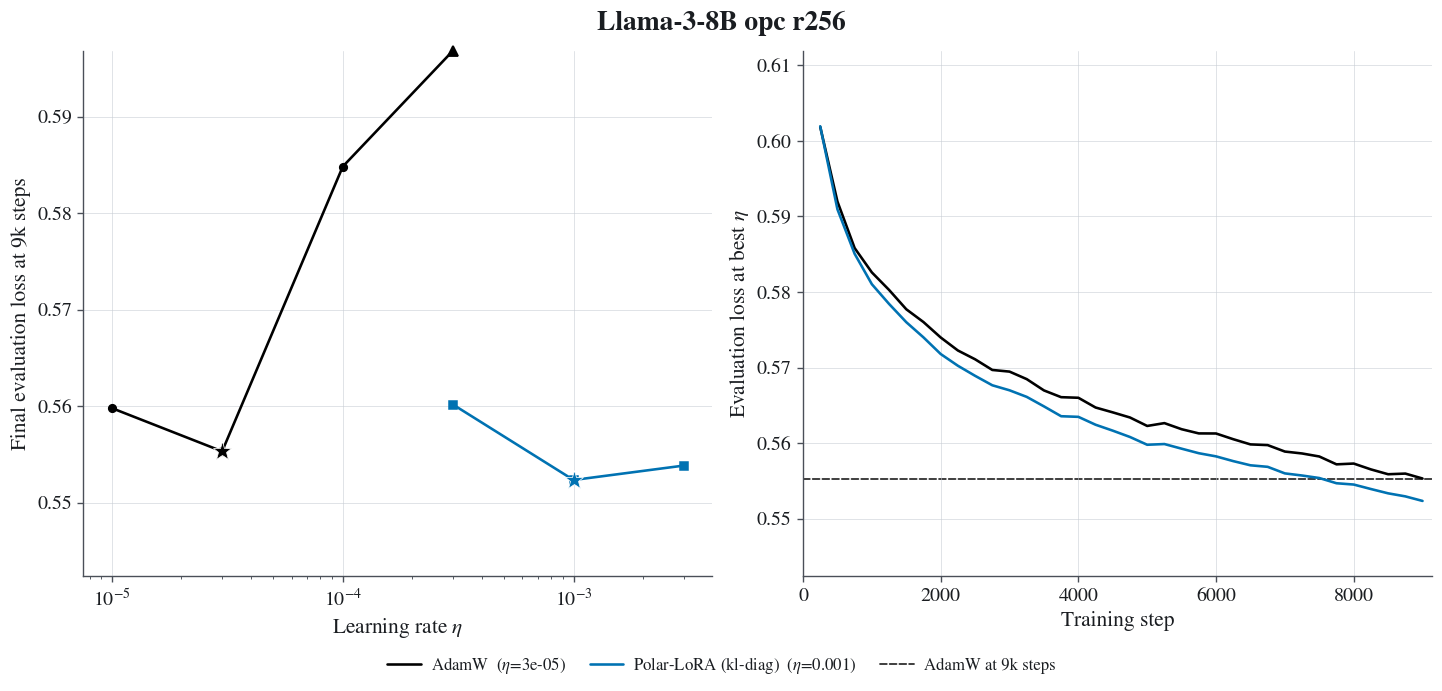

speedup vs AdamW (target 0.5553, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.001   0.5523     1.20x    1.09x  3
  AdamW                     3e-05   0.5553     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.555303,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00100,0.552333,-0.00297,-1.747025,1


In [70]:
P.panel_n(3)   # Llama-3-8B opc r256


#### Figure 5. Qwen2.5-1.5B · Bengali · r=256 (OOD pair)

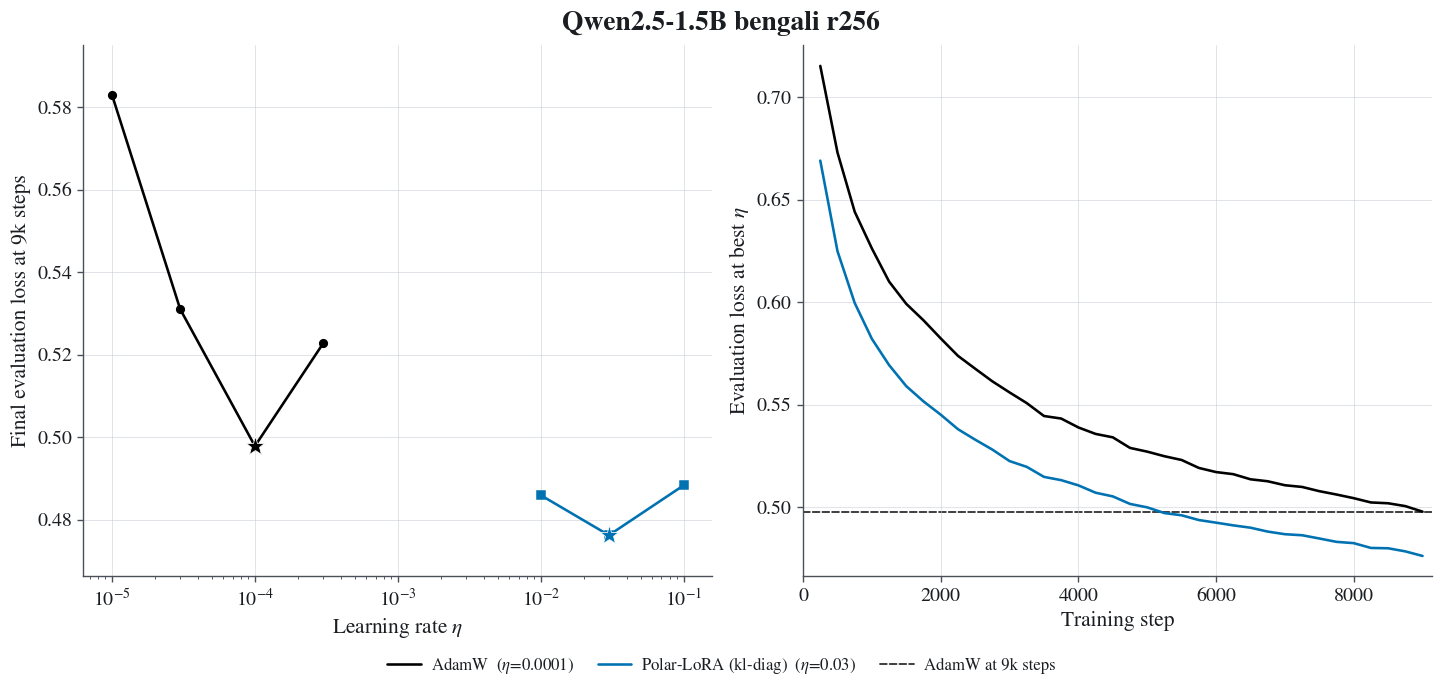

speedup vs AdamW (target 0.4979, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.03   0.4763     1.73x    1.39x  3
  AdamW                    0.0001   0.4979     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.497858,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0300,0.476251,-0.021607,-12.710198,1


In [71]:
P.panel_n(4)   # Qwen2.5-1.5B bengali r256


### Math workload breadth

#### Figure 6. OLMo-2-1B · OpenMath · r=256

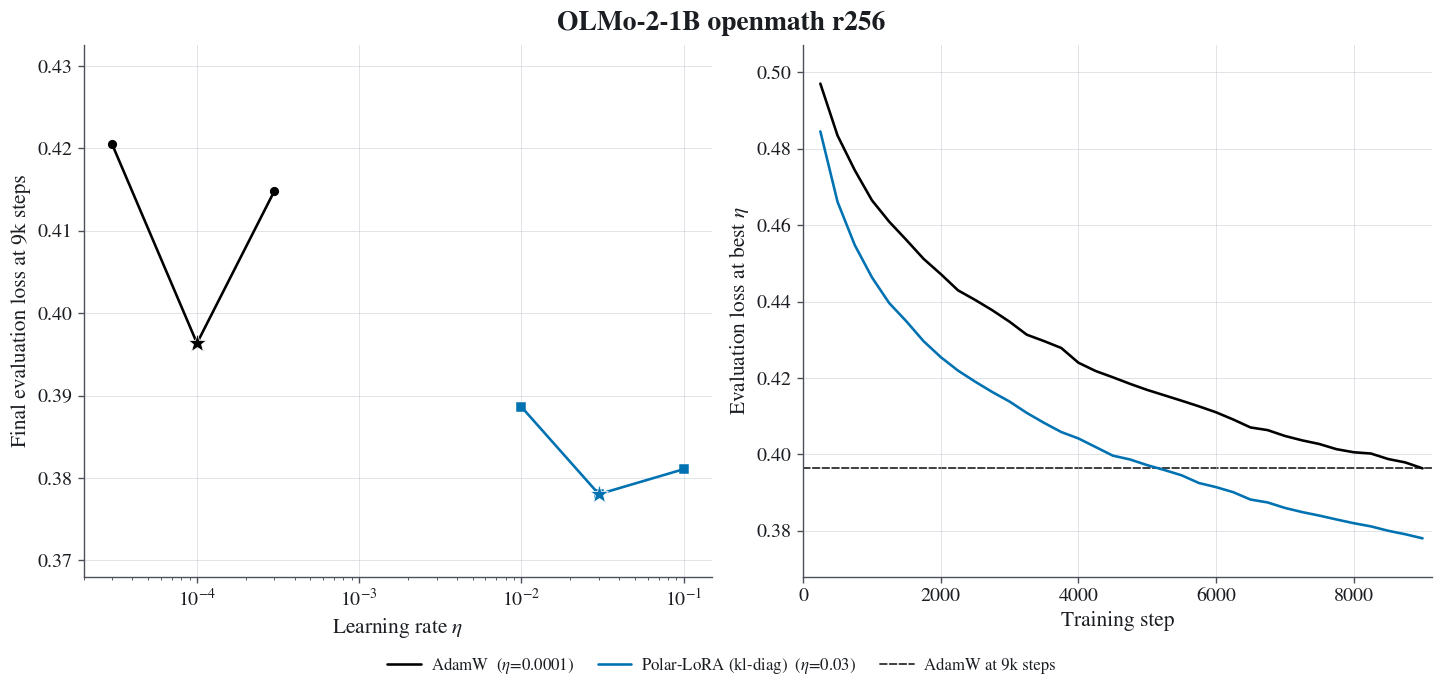

speedup vs AdamW (target 0.3964, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.03   0.3780     1.74x    1.50x  3
  AdamW                    0.0001   0.3964     1.00x    1.00x  3


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.396363,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0300,0.378044,-0.01832,-10.77627,1


In [72]:
P.panel_n(5)   # OLMo-2-1B openmath r256


#### Figure 7. Qwen2.5-1.5B · OpenMath · r=256

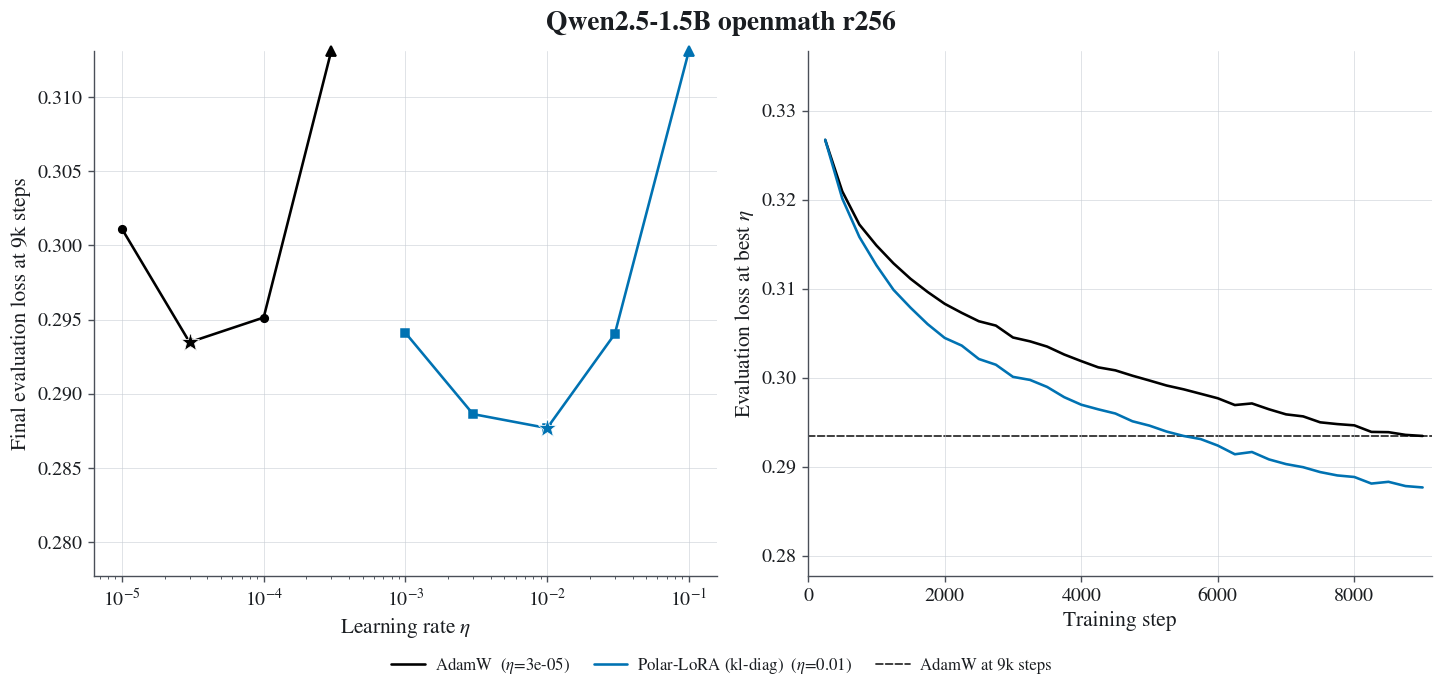

speedup vs AdamW (target 0.2935, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.2877     1.64x    1.33x  5
  AdamW                     3e-05   0.2935     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.293472,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.01000,0.287687,-0.005785,-3.402839,1


In [73]:
P.panel_n(6)   # Qwen2.5-1.5B openmath r256


#### Figure 8. Llama-3-8B · OpenMath · r=256

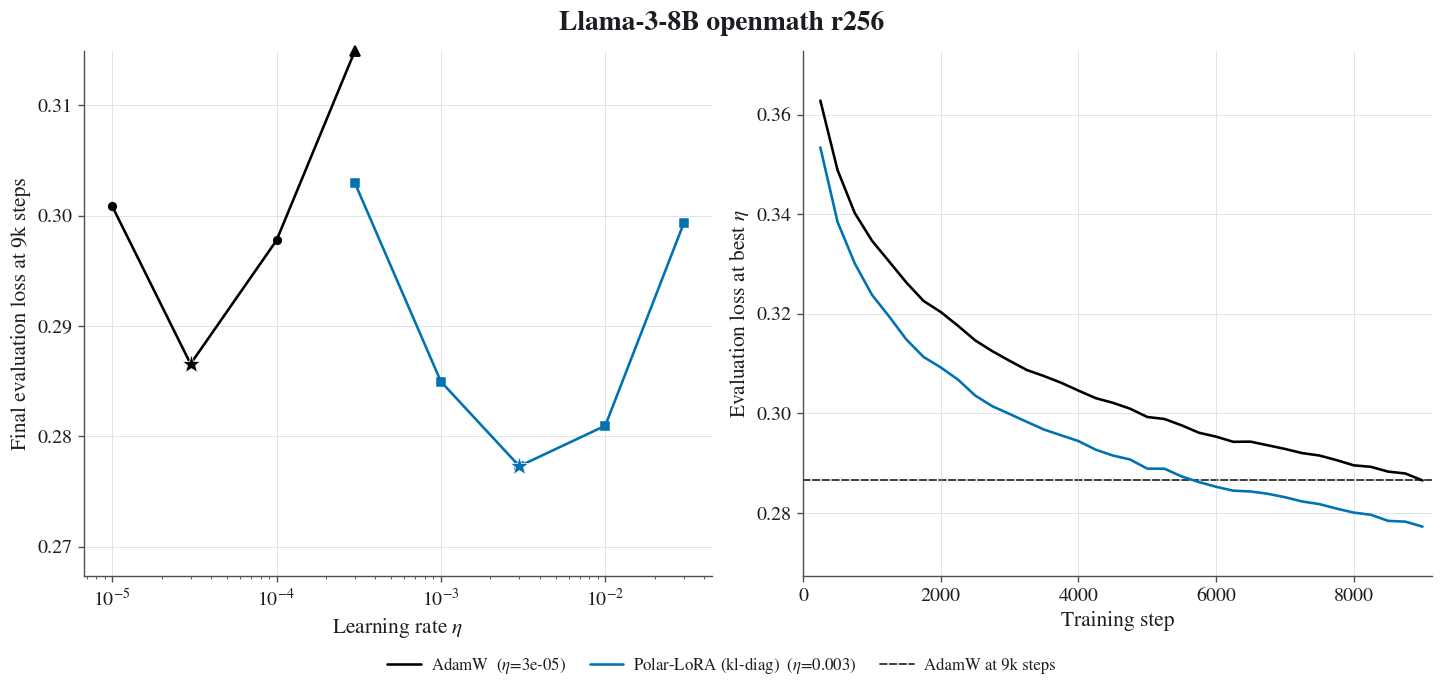

speedup vs AdamW (target 0.2866, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.003   0.2773     1.59x    1.25x  5
  AdamW                     3e-05   0.2866     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.286564,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.00300,0.277293,-0.00927,-5.452999,1


In [74]:
P.panel_n(7)   # Llama-3-8B openmath r256


### Rank transfer on Llama-3.2-1B · OpenMath

#### Figure 9. r=16

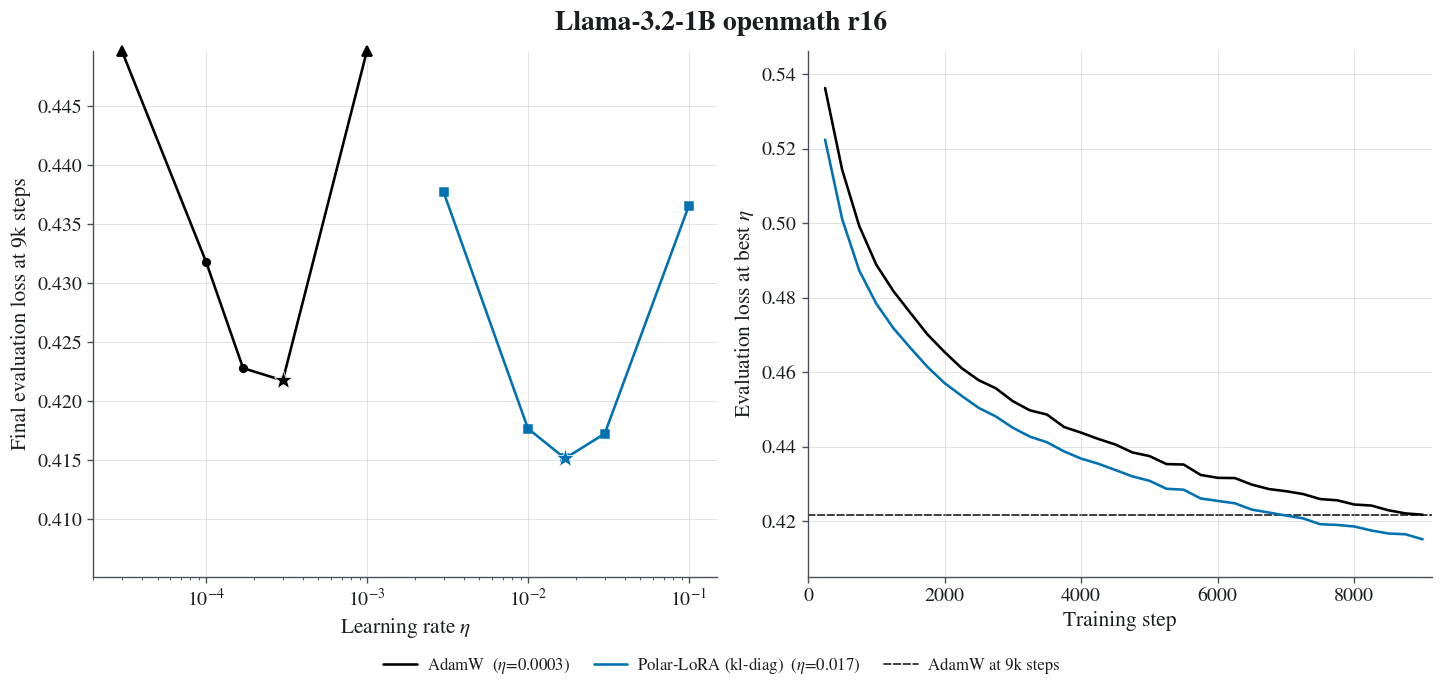

speedup vs AdamW (target 0.4218, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)      0.017   0.4152     1.30x    1.23x  5
  AdamW                    0.0003   0.4218     1.00x    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.421763,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0170,0.415162,-0.006601,-3.883152,1


In [75]:
P.panel_n(8)   # Llama-3.2-1B openmath r16


#### Figure 10. r=32

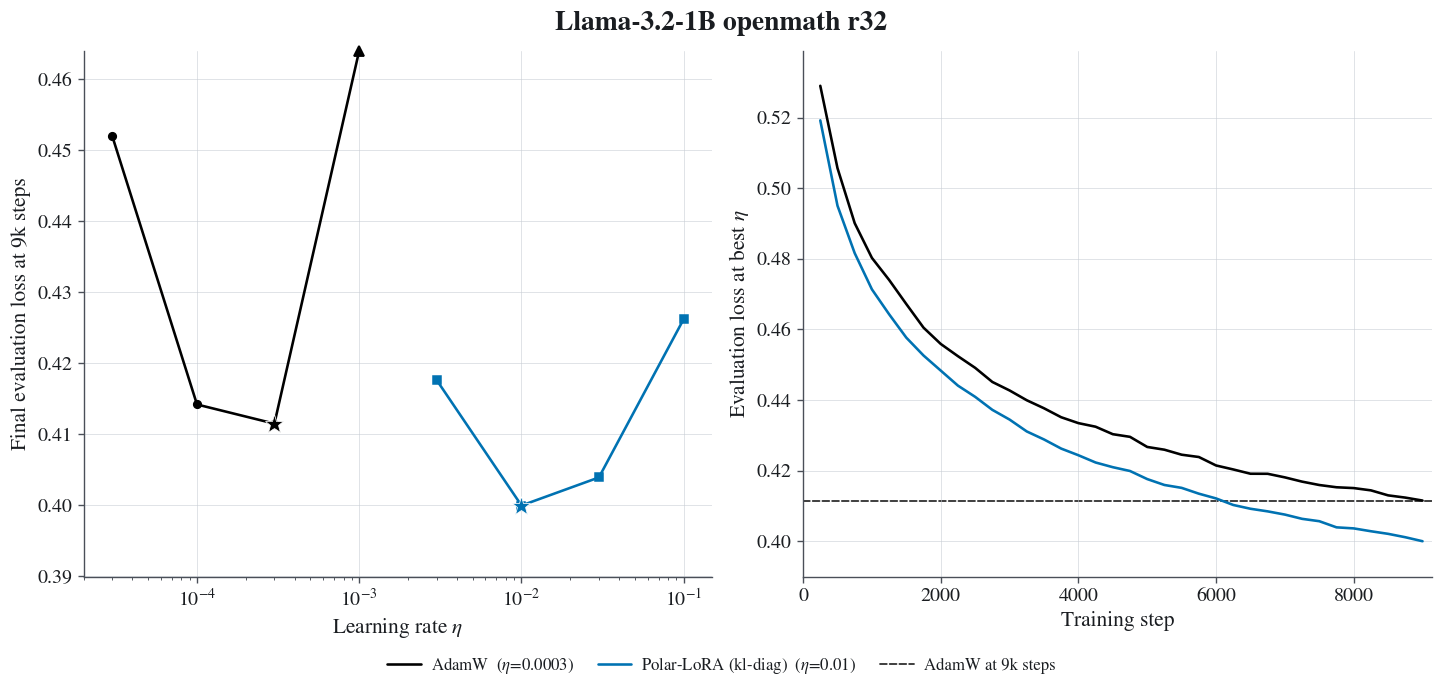

speedup vs AdamW (target 0.4115, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.4000     1.48x    1.23x  4
  AdamW                    0.0003   0.4115     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.411517,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0100,0.399991,-0.011526,-6.779981,1


In [76]:
P.panel_n(9)   # Llama-3.2-1B openmath r32


#### Figure 11. r=64

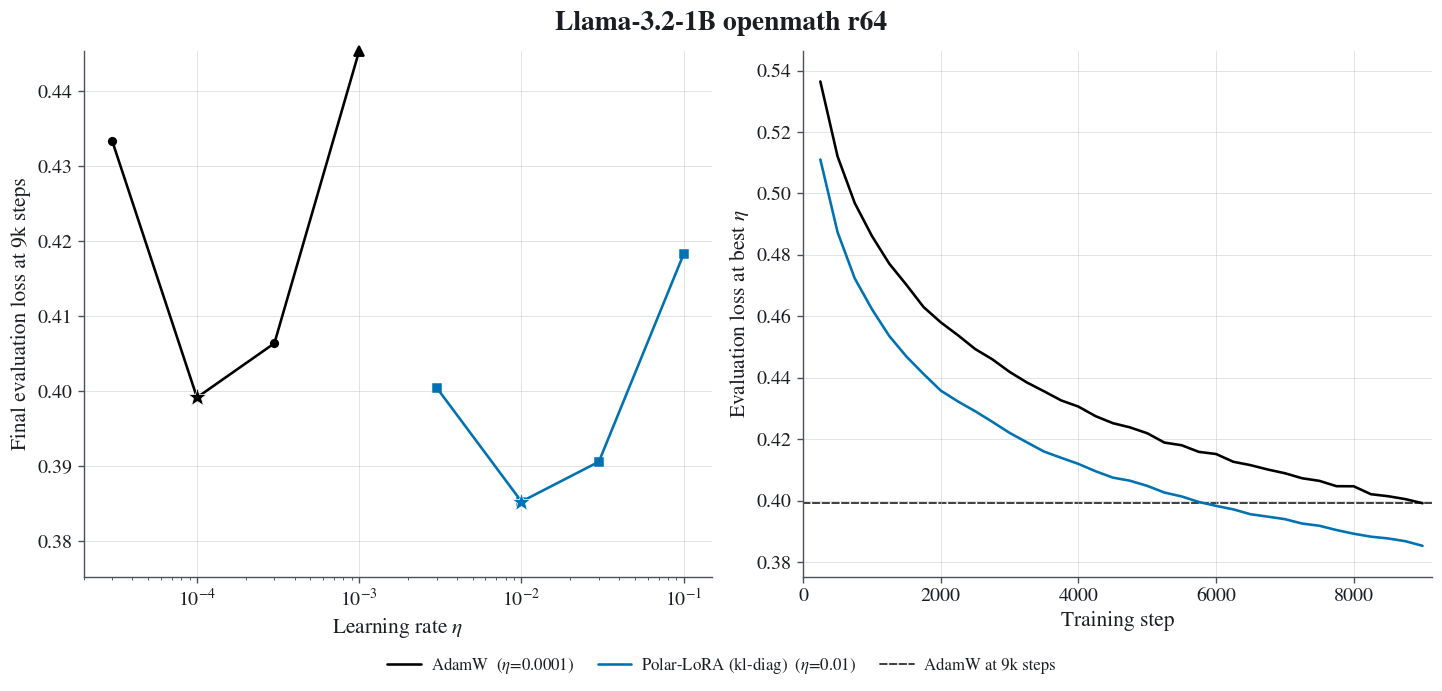

speedup vs AdamW (target 0.3991, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.3853     1.54x    1.25x  4
  AdamW                    0.0001   0.3991     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.399128,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0100,0.385254,-0.013874,-8.160944,1


In [77]:
P.panel_n(10)   # Llama-3.2-1B openmath r64


#### Figure 12. r=128

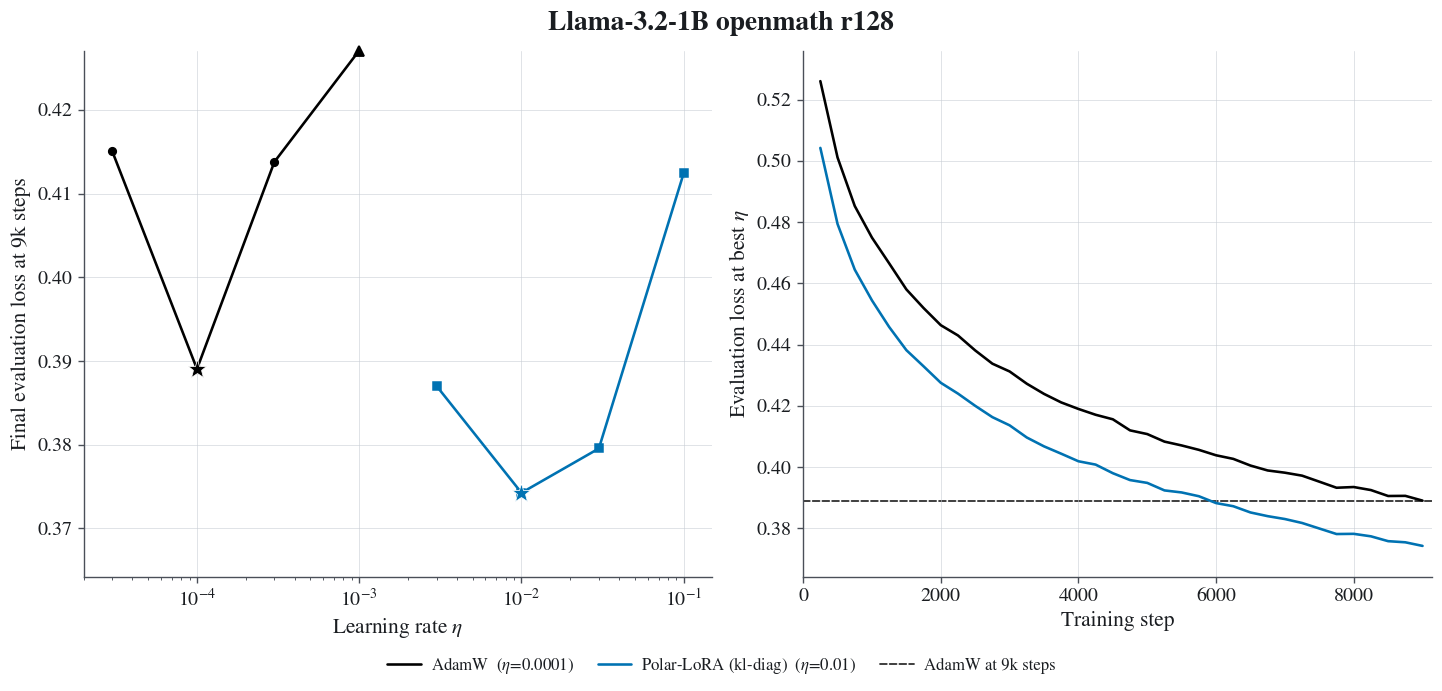

speedup vs AdamW (target 0.3890, horizon 9000)
  arm                    best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)       0.01   0.3743     1.52x    1.28x  4
  AdamW                    0.0001   0.3890     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.389044,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.0100,0.374259,-0.014785,-8.696915,1


In [78]:
P.panel_n(11)   # Llama-3.2-1B openmath r128


#### Figure 13. r=256

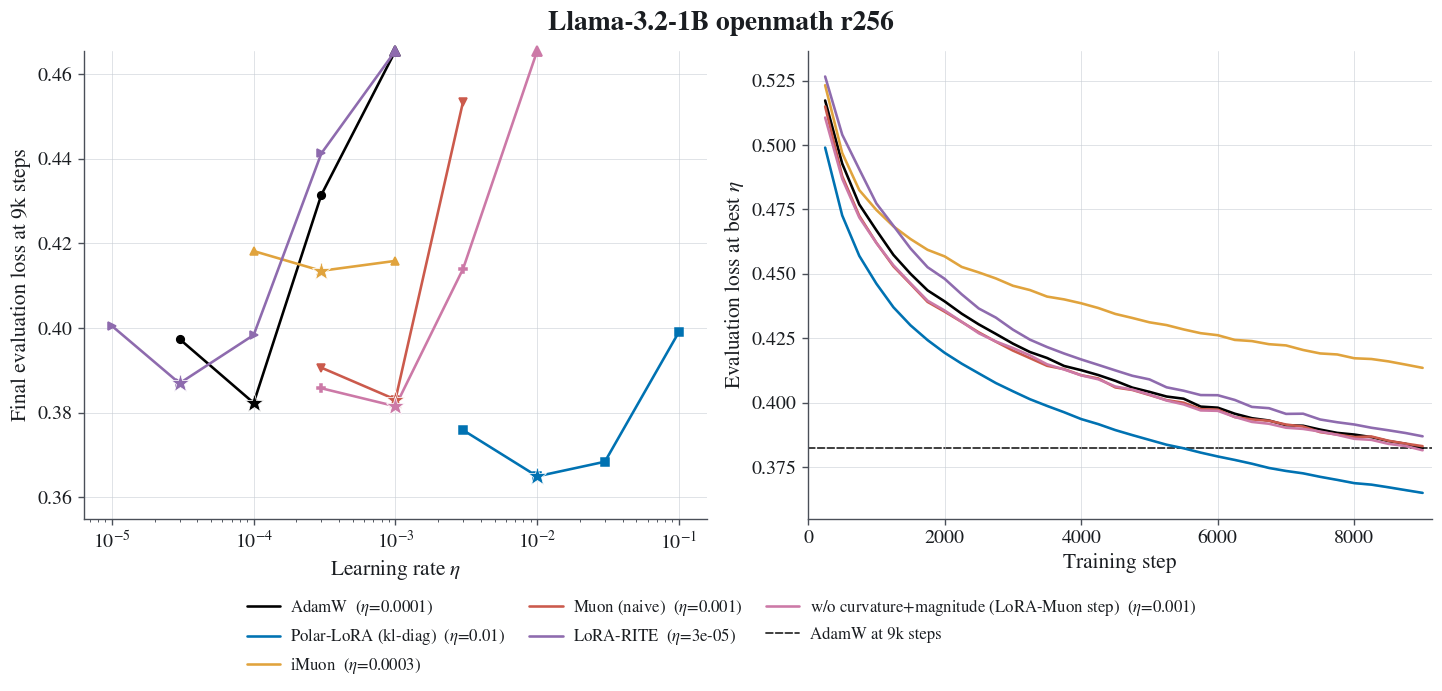

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                        best eta    final   speedup   lr-avg  n_lr
  Polar-LoRA (kl-diag)                           0.01   0.3650     1.64x    1.40x  4
  w/o curvature+magnitude (LoRA-Muon step)      0.001   0.3815     1.01x    1.00x  4
  AdamW                                        0.0001   0.3823     1.00x    1.00x  4
  iMuon                                        0.0003   0.4135         —    1.00x  3
  Muon (naive)                                  0.001   0.3831         —    1.00x  3
  LoRA-RITE                                     3e-05   0.3869         —    1.00x  5


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00010,0.382301,NaN,NaN,1
1,Polar-LoRA (kl-diag),0.01000,0.364971,-0.017329,-10.193808,4
2,iMuon,0.00030,0.413505,0.031204,18.355461,1
3,Muon (naive),0.00100,0.383107,0.000807,0.474588,1
4,LoRA-RITE,0.00003,0.386939,0.004638,2.728313,1
5,w/o curvature+magnitude (LoRA-Muon step),0.00100,0.381511,-0.000790,-0.464564,1


In [79]:
P.panel_n(12)   # Llama-3.2-1B openmath r256


The overlay below asks whether the preferred learning-rate basin transfers across the full rank ladder.

### Figure 14. Rank-ladder final loss versus learning rate

── fig3 lr transfer (openmath rank ladder) ──
  r16 PoLoRA       best_lr 0.017  final 0.4152
  r16 Adam         best_lr 0.0003  final 0.4218
  r32 PoLoRA       best_lr 0.01  final 0.4000
  r32 Adam         best_lr 0.0003  final 0.4115
  r64 PoLoRA       best_lr 0.01  final 0.3853
  r64 Adam         best_lr 0.0001  final 0.3991
  r128 PoLoRA       best_lr 0.01  final 0.3743
  r128 Adam         best_lr 0.0001  final 0.3890
  r256 PoLoRA       best_lr 0.01  final 0.3650
  r256 Adam         best_lr 0.0001  final 0.3823


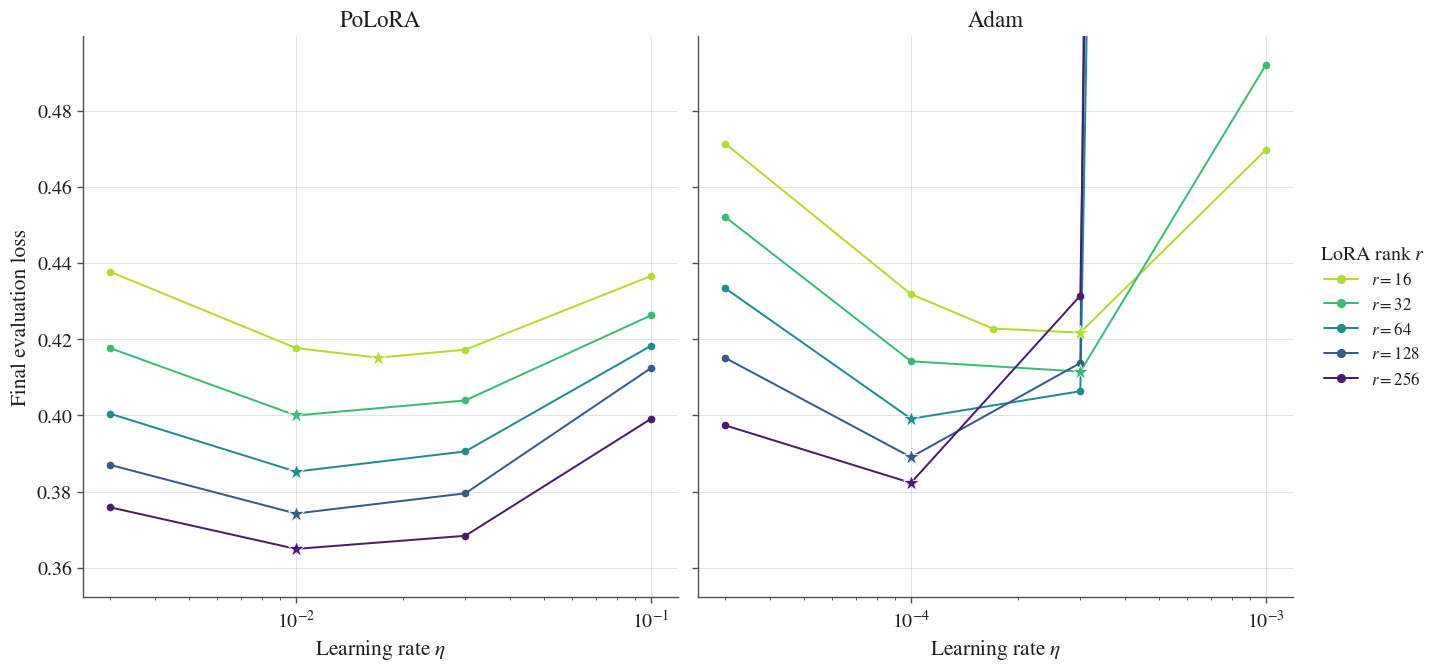

In [80]:
# Final eval loss vs learning rate across the Llama openmath rank ladder.
# The shared records-native function owns loading, aggregation, and rendering.
P.rank_lr_panel();


## Question 2 — Which update ingredients drive the gain?

### Figure 15. Component ablation

no data yet (omitted): No magnitude rule: $\Delta A=-\eta W_A$


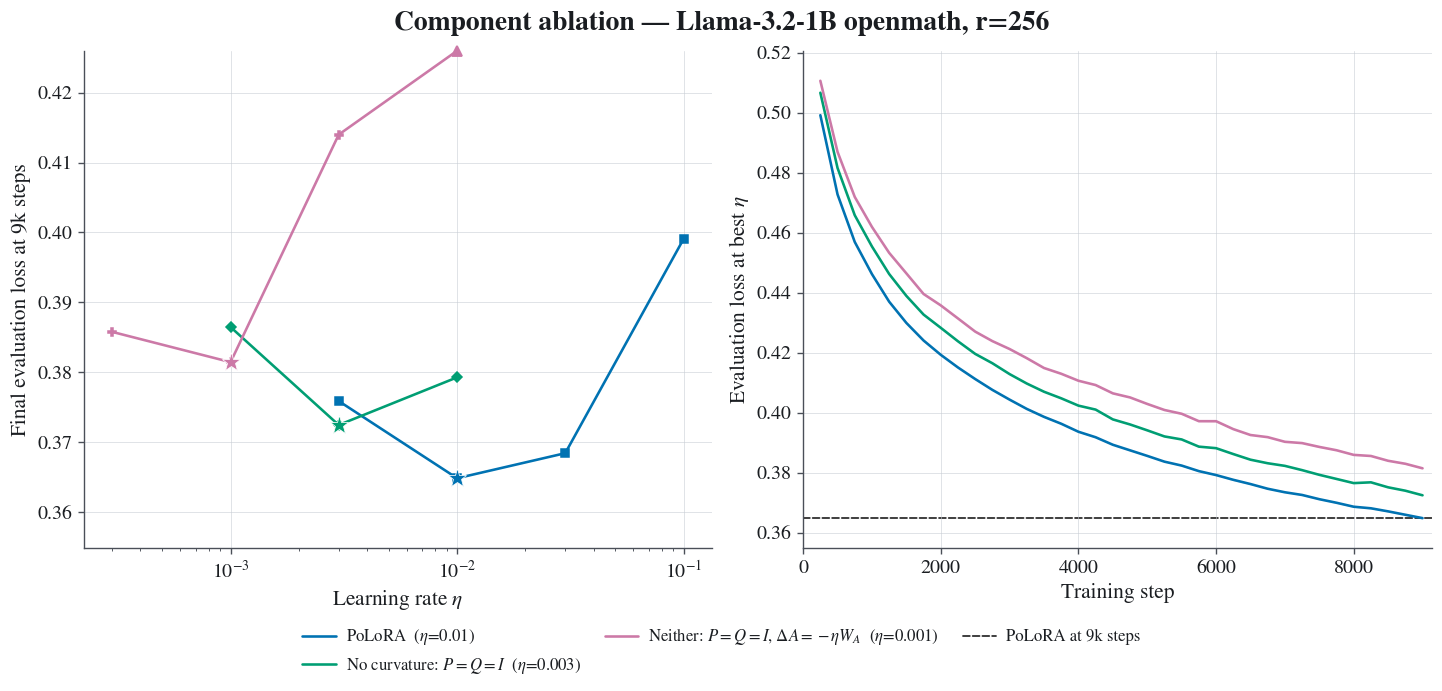

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,PoLoRA,0.010,0.364831,NaN,NaN,5
1,No curvature: $P=Q=I$,0.003,0.372446,0.007615,4.479246,1
2,"Neither: $P=Q=I$, $\Delta A=-\eta W_A$",0.001,0.381439,0.016608,9.769597,2


In [81]:
P.ablation_panel(256)


### Figure 16. Orthogonalization versus metric power

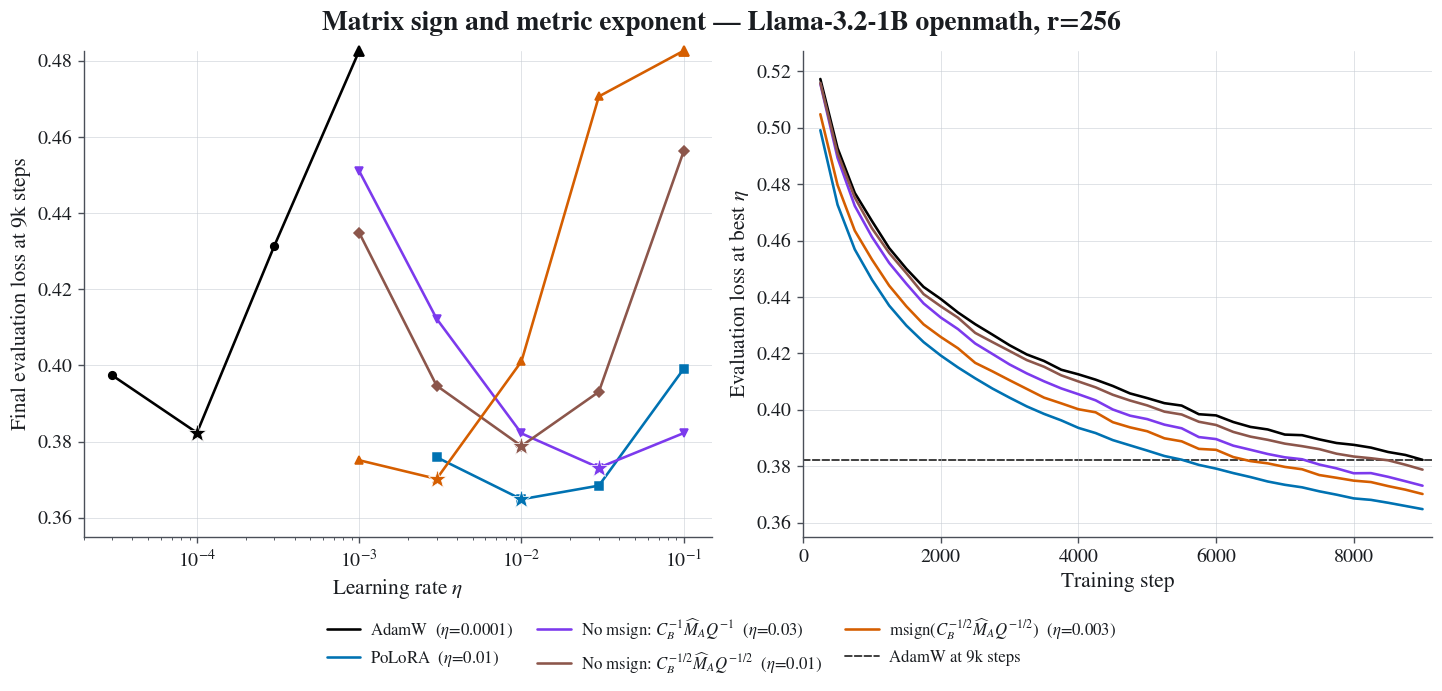

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                                      best eta    final   speedup   lr-avg  n_lr
  PoLoRA                                                       0.01   0.3648     1.63x    1.40x  4
  $\mathrm{msign}(C_B^{-1/2}\widehat{M}_AQ^{-1/2})$           0.003   0.3702     1.40x    1.18x  5
  No $\mathrm{msign}$: $C_B^{-1}\widehat{M}_AQ^{-1}$           0.03   0.3731     1.24x    1.07x  5
  No $\mathrm{msign}$: $C_B^{-1/2}\widehat{M}_AQ^{-1/2}$       0.01   0.3788     1.07x    1.02x  5
  AdamW                                                      0.0001   0.3823     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.382301,0.017470,10.276285,1
1,PoLoRA,0.0100,0.364831,NaN,NaN,5
2,No $\mathrm{msign}$: $C_B^{-1}\widehat{M}_AQ^{...,0.0300,0.373131,0.008300,4.882538,2
3,No $\mathrm{msign}$: $C_B^{-1/2}\widehat{M}_AQ...,0.0100,0.378824,0.013993,8.231263,1
4,$\mathrm{msign}(C_B^{-1/2}\widehat{M}_AQ^{-1/2})$,0.0030,0.370188,0.005357,3.151343,1


In [82]:
P.derivation_ablation_panel(256)


### Figure 17. Full versus diagonal matrix sign

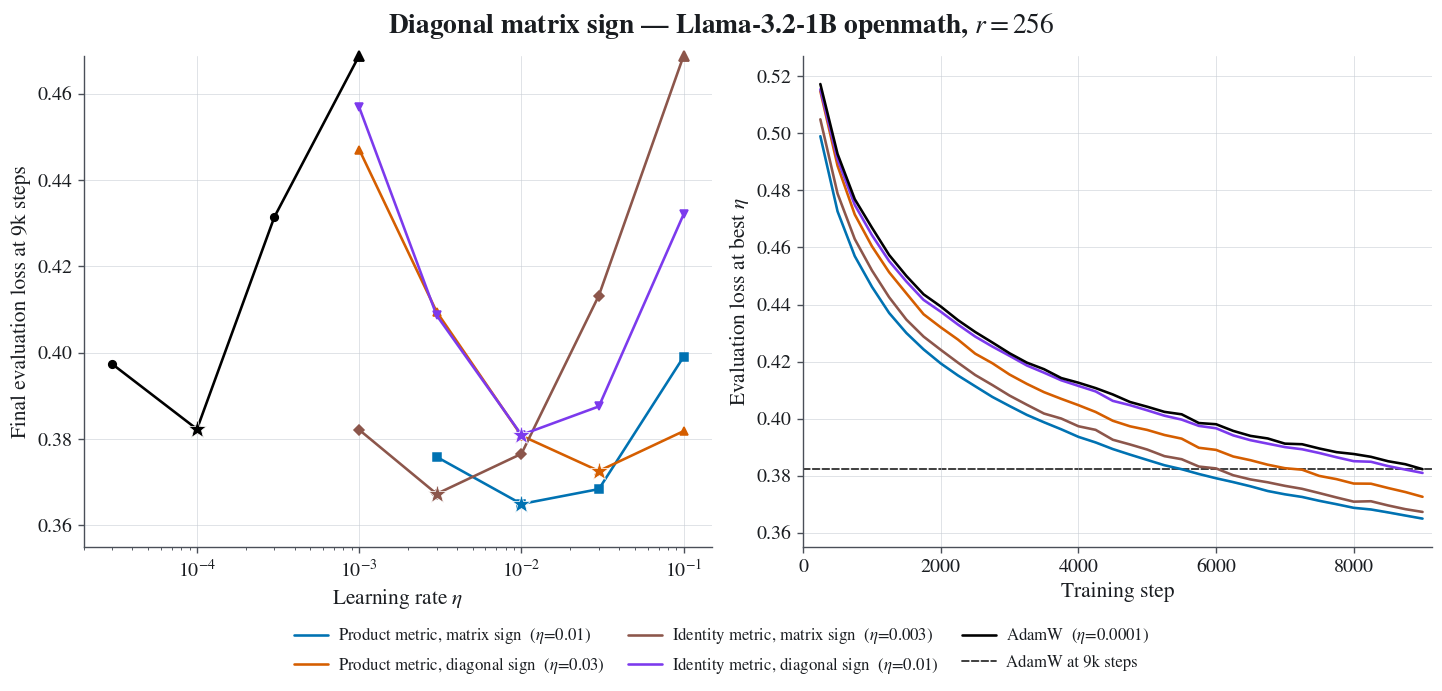

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                              best eta    final   speedup   lr-avg  n_lr
  Product metric, matrix sign          0.01   0.3650     1.64x    1.40x  4
  Identity metric, matrix sign        0.003   0.3673     1.49x    1.20x  5
  Product metric, diagonal sign        0.03   0.3726     1.26x    1.09x  5
  Identity metric, diagonal sign       0.01   0.3810     1.03x    1.01x  5
  AdamW                              0.0001   0.3823     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,"Product metric, matrix sign",0.0100,0.364971,NaN,NaN,4
1,"Product metric, diagonal sign",0.0300,0.372614,0.007642,4.495528,1
2,"Identity metric, matrix sign",0.0030,0.367310,0.002339,1.375909,1
3,"Identity metric, diagonal sign",0.0100,0.380976,0.016005,9.414755,1
4,AdamW,0.0001,0.382301,0.017329,10.193808,1


In [83]:
P.msign_panel(256)


### Figure 18. Matrix sign by slot content — the third row

`paper.msign.v1` above is sealed over the `product` and `one-sided` rows, so the
cross it shows is 2x2 where the two axes are 3x2: `msign` is orthogonal to
`precond`, so whether the diagonal sign suffices can differ per slot content.
This adds the `factorwise` row.

**Plotted:** final eval loss vs learning rate and the best-lr trajectory for all
three slot contents at both sign accuracies, with AdamW for scale.
**Why:** the discriminating feature is whether the full-vs-diagonal gap depends
on what fills $C_B$, $C_A$. The factorwise diagonal arm is still in flight and
renders as a partial trajectory.

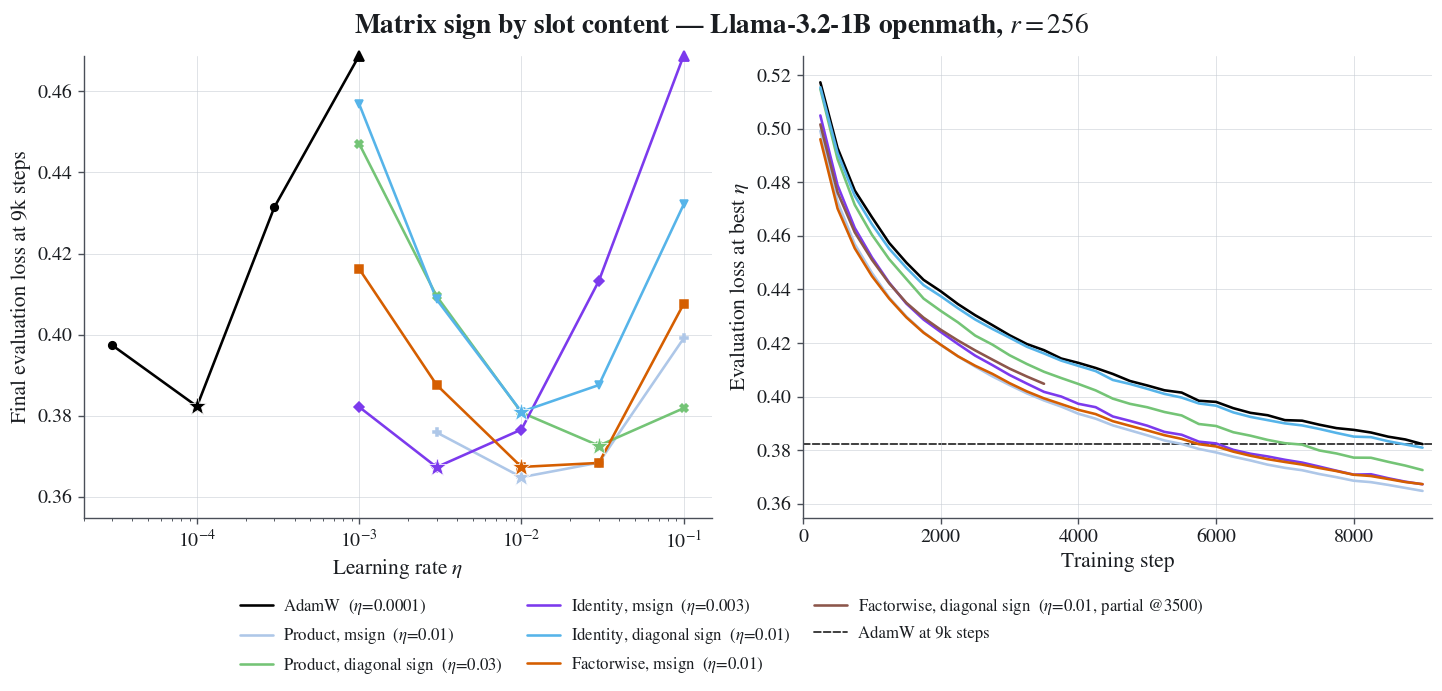

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                            best eta    final   speedup   lr-avg  n_lr
  Product, $\mathrm{msign}$          0.01   0.3648     1.63x    1.40x  4
  Factorwise, $\mathrm{msign}$       0.01   0.3674     1.57x    1.30x  5
  Identity, $\mathrm{msign}$        0.003   0.3673     1.49x    1.20x  5
  Product, diagonal sign             0.03   0.3726     1.26x    1.09x  5
  Identity, diagonal sign            0.01   0.3810     1.03x    1.01x  5
  AdamW                            0.0001   0.3823     1.00x    1.00x  4
13 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.382301,0.017470,10.276285,1
1,"Product, $\mathrm{msign}$",0.0100,0.364831,NaN,NaN,5
2,"Product, diagonal sign",0.0300,0.372614,0.007783,4.578005,1
3,"Identity, $\mathrm{msign}$",0.0030,0.367310,0.002479,1.458386,1
4,"Identity, diagonal sign",0.0100,0.380976,0.016145,9.497232,1
5,"Factorwise, $\mathrm{msign}$",0.0100,0.367361,0.002530,1.488263,1


In [84]:
P.msign_by_precond_panel(256)

### Figure 19. Spectral-norm magnitude rule versus naive ρ=η

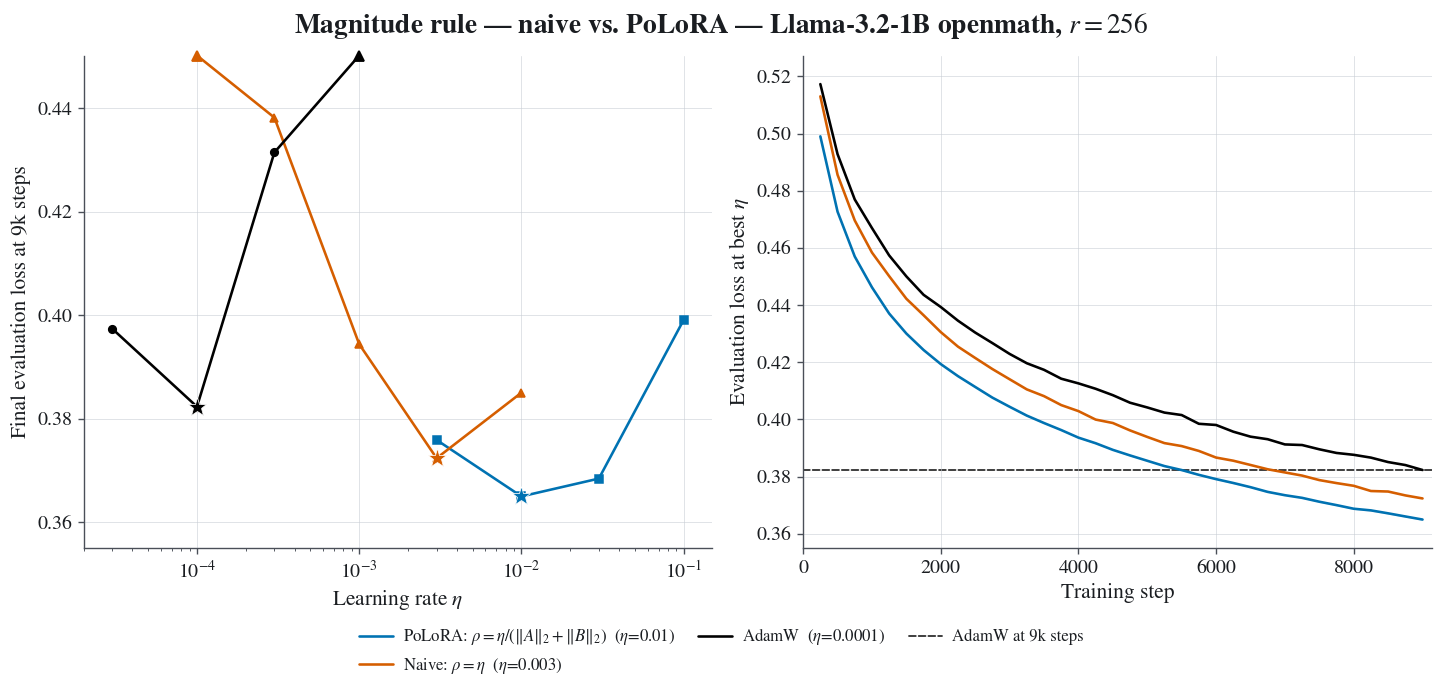

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                     best eta    final   speedup   lr-avg  n_lr
  PoLoRA: $\rho=\eta/(\|A\|_2+\|B\|_2)$       0.01   0.3650     1.64x    1.40x  4
  Naive: $\rho=\eta$                         0.003   0.3724     1.32x    1.09x  5
  AdamW                                     0.0001   0.3823     1.00x    1.00x  4


,variant,best_lr,final,delta,delta_sigma,n
0,PoLoRA: $\rho=\eta/(\|A\|_2+\|B\|_2)$,0.0100,0.364971,NaN,NaN,4
1,Naive: $\rho=\eta$,0.0030,0.372352,0.007380,4.341388,1
2,AdamW,0.0001,0.382301,0.017329,10.193808,1


In [85]:
P.magnitude_rule_panel(256)


## Question 3 — What should fill the r×r metric slot, and does the answer transfer?

### Figure 20. Llama-3.2-1B · OpenMath · r=16

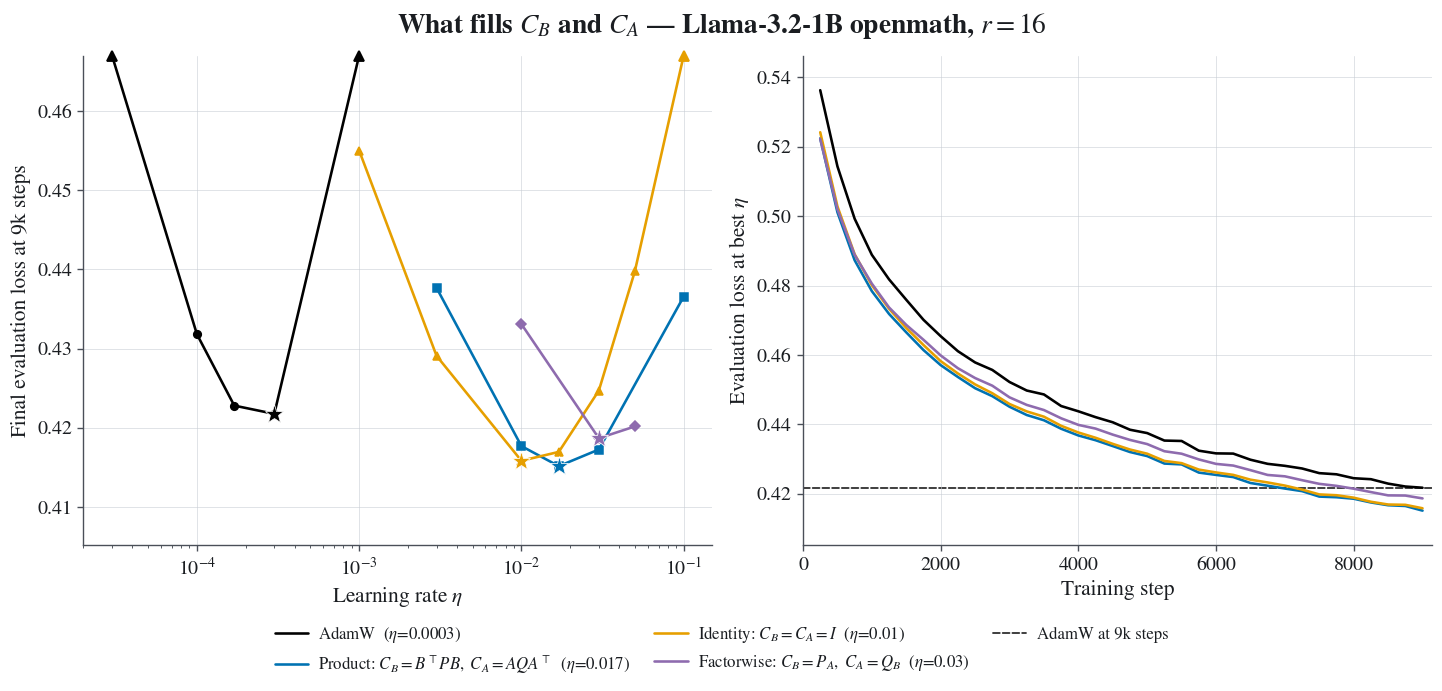

speedup vs AdamW (target 0.4218, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$      0.017   0.4152     1.30x    1.23x  5
  Identity: $C_B=C_A=I$                            0.01   0.4158     1.26x    1.15x  7
  Factorwise: $C_B=P_A,\ C_A=Q_B$                  0.03   0.4187     1.14x    1.06x  3
  AdamW                                          0.0003   0.4218     1.00x    1.00x  5
7 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.421763,0.006601,3.883152,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.0170,0.415162,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.0100,0.415841,0.000679,0.399347,2
3,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.0300,0.418685,0.003523,2.072627,1


In [86]:
P.precond_panel(16)


### Figure 21. Llama-3.2-1B · OpenMath · r=64

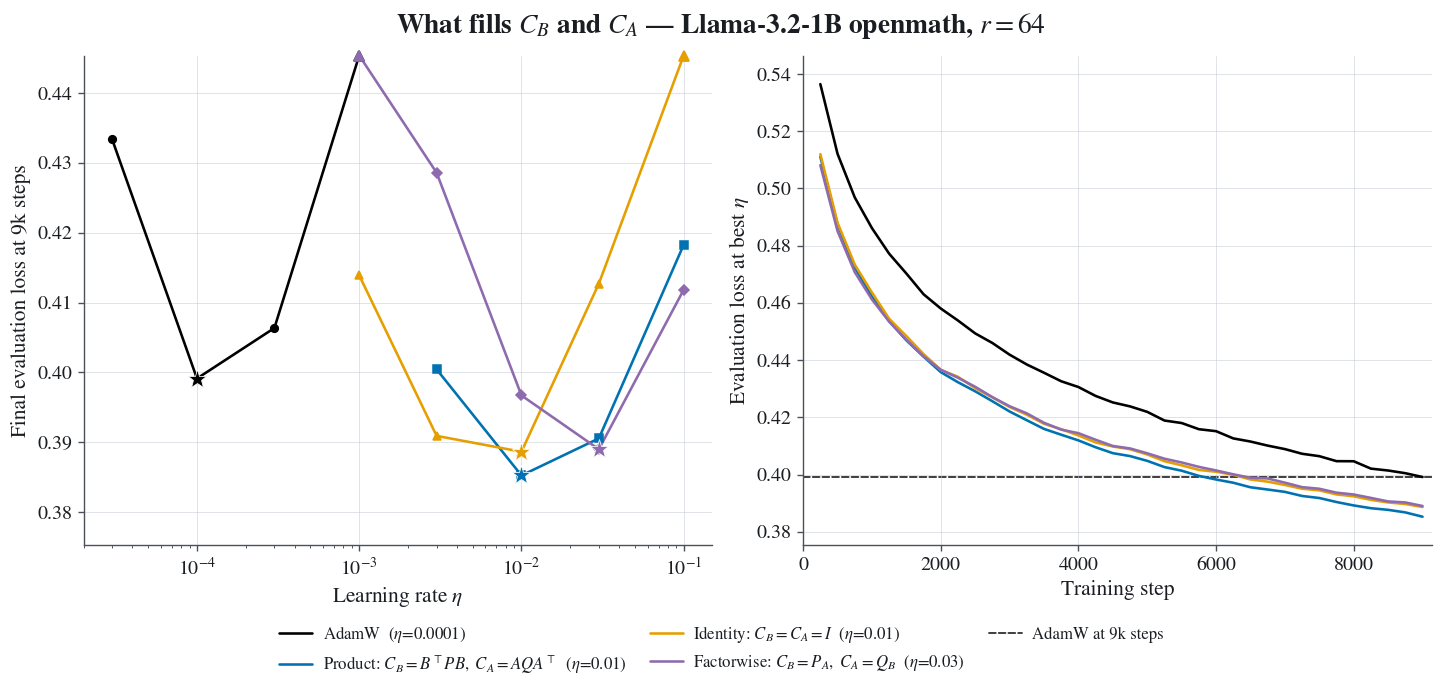

speedup vs AdamW (target 0.3991, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$       0.01   0.3853     1.54x    1.25x  4
  Identity: $C_B=C_A=I$                            0.01   0.3886     1.41x    1.20x  5
  Factorwise: $C_B=P_A,\ C_A=Q_B$                  0.03   0.3890     1.40x    1.13x  5
  AdamW                                          0.0001   0.3991     1.00x    1.00x  4
5 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.399128,0.013874,8.160944,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.0100,0.385254,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.0100,0.388649,0.003395,1.996805,1
3,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.0300,0.389001,0.003746,2.203664,1


In [87]:
P.precond_panel(64)


### Figure 22. Llama-3.2-1B · OpenMath · r=256

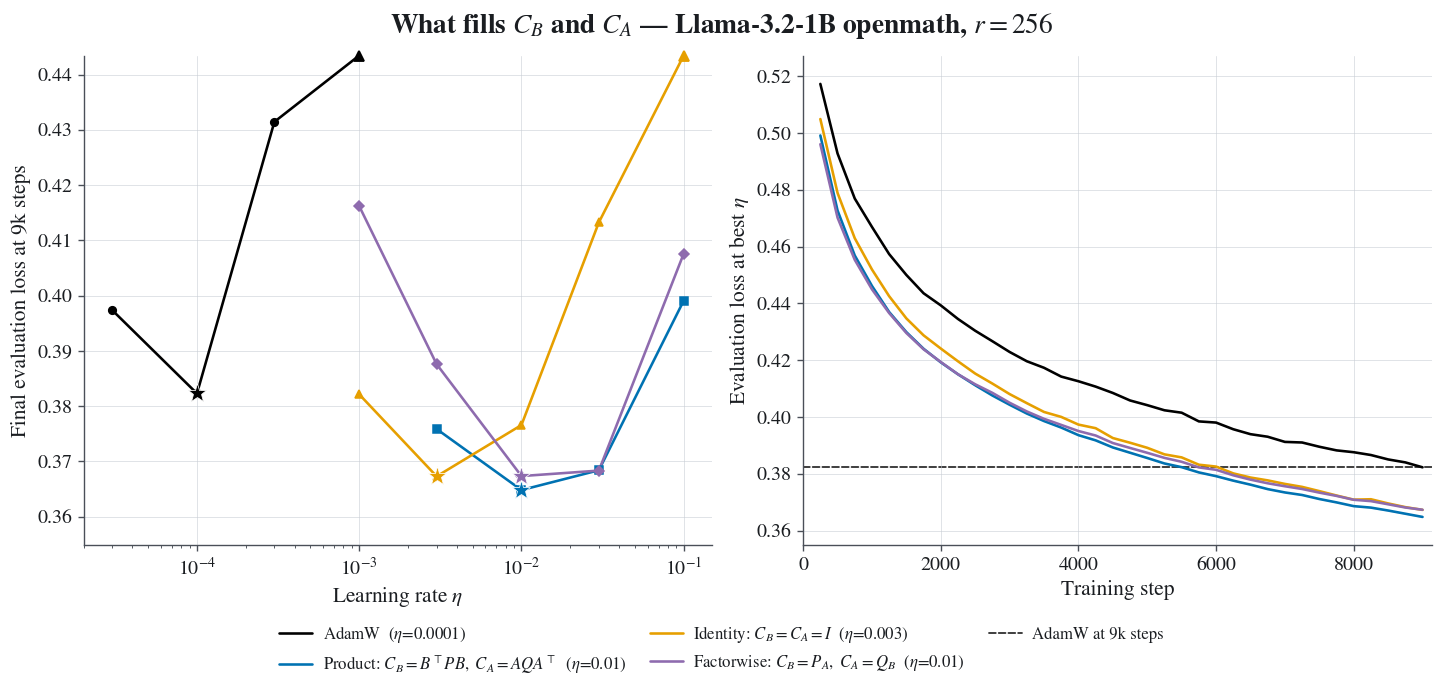

speedup vs AdamW (target 0.3823, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$       0.01   0.3648     1.63x    1.40x  4
  Factorwise: $C_B=P_A,\ C_A=Q_B$                  0.01   0.3674     1.57x    1.30x  5
  Identity: $C_B=C_A=I$                           0.003   0.3673     1.49x    1.20x  5
  AdamW                                          0.0001   0.3823     1.00x    1.00x  4
13 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0001,0.382301,0.017470,10.276285,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.0100,0.364831,NaN,NaN,5
2,Identity: $C_B=C_A=I$,0.0030,0.367310,0.002479,1.458386,1
3,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.0100,0.367361,0.002530,1.488263,1


In [88]:
P.precond_panel(256)


### Figure 23. Qwen2.5-1.5B · OpenMath · r=16

no speed target: AdamW has no completed run in Qwen2.5/openmath/r16.


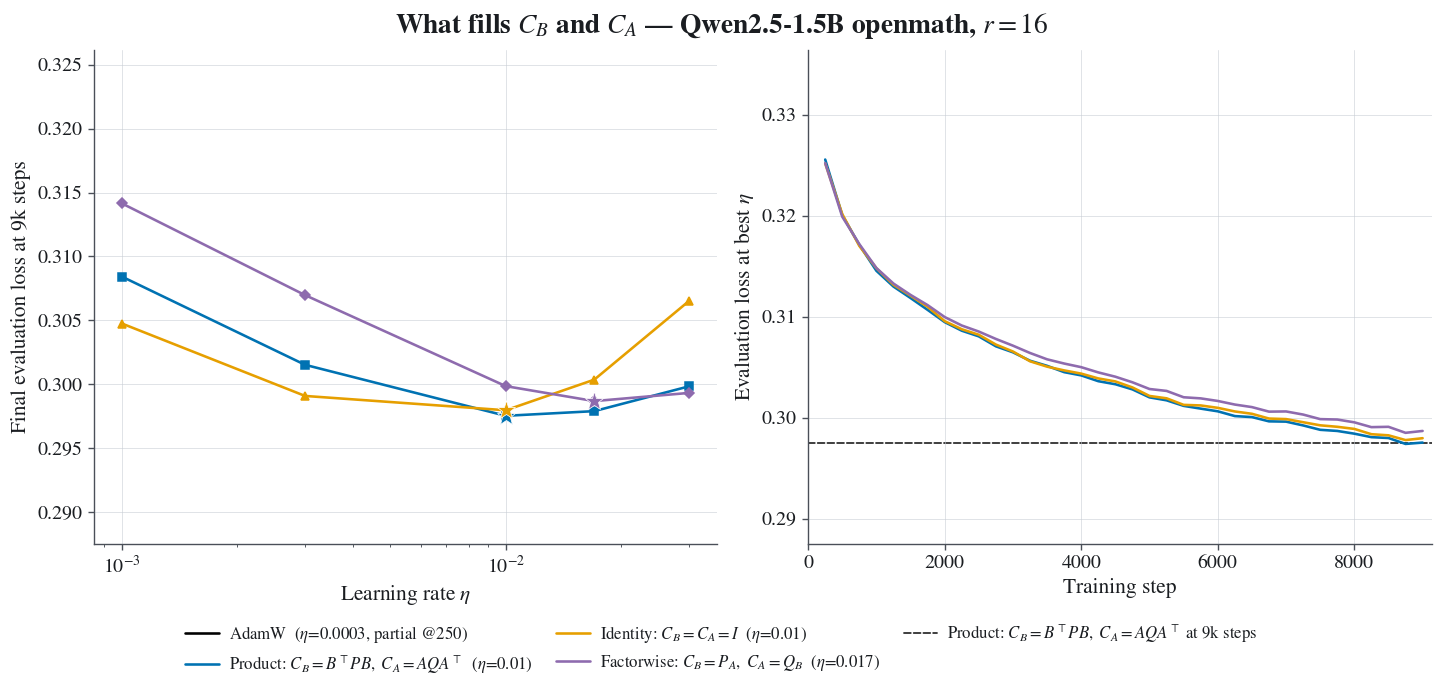

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.010,0.297525,NaN,NaN,1
1,Identity: $C_B=C_A=I$,0.010,0.297959,0.000435,0.255607,1
2,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.017,0.298677,0.001152,0.677882,1


In [89]:
P.precond_panel(
    16,
    model="Qwen/Qwen2.5-1.5B",
    model_label="Qwen2.5-1.5B",
    matched_revision=True,
)


### Figure 24. Qwen2.5-1.5B · OpenMath · r=256

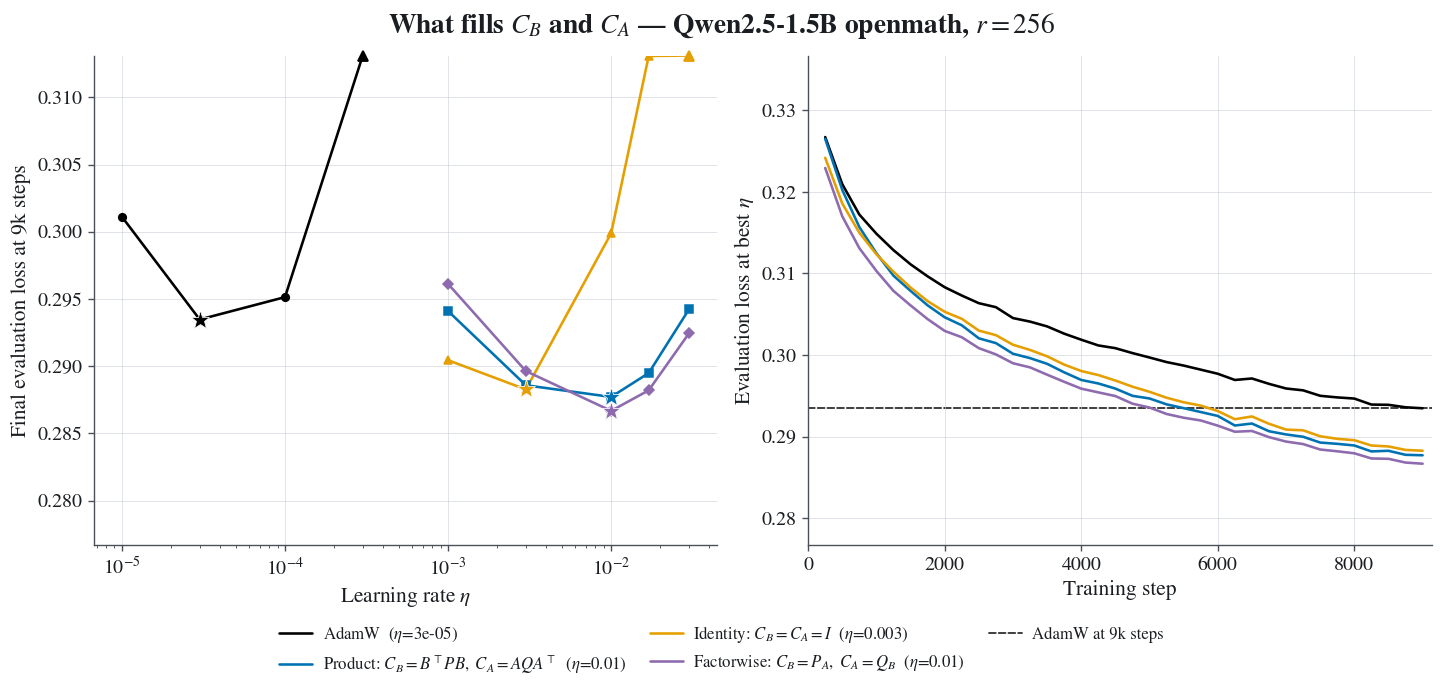

speedup vs AdamW (target 0.2935, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Factorwise: $C_B=P_A,\ C_A=Q_B$                  0.01   0.2867     1.79x    1.59x  5
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$       0.01   0.2877     1.63x    1.55x  5
  Identity: $C_B=C_A=I$                           0.003   0.2883     1.53x    1.25x  5
  AdamW                                           3e-05   0.2935     1.00x    1.00x  4
15 run(s) excluded by 'precond_matched' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.293472,0.005763,3.389774,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.01000,0.287709,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.00300,0.288268,0.000559,0.328974,1
3,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.01000,0.286675,-0.001034,-0.608374,1


In [90]:
P.precond_panel(
    256,
    model="Qwen/Qwen2.5-1.5B",
    model_label="Qwen2.5-1.5B",
    matched_revision=True,
)


### Figure 25. Llama-3.2-1B · OPC · r=256

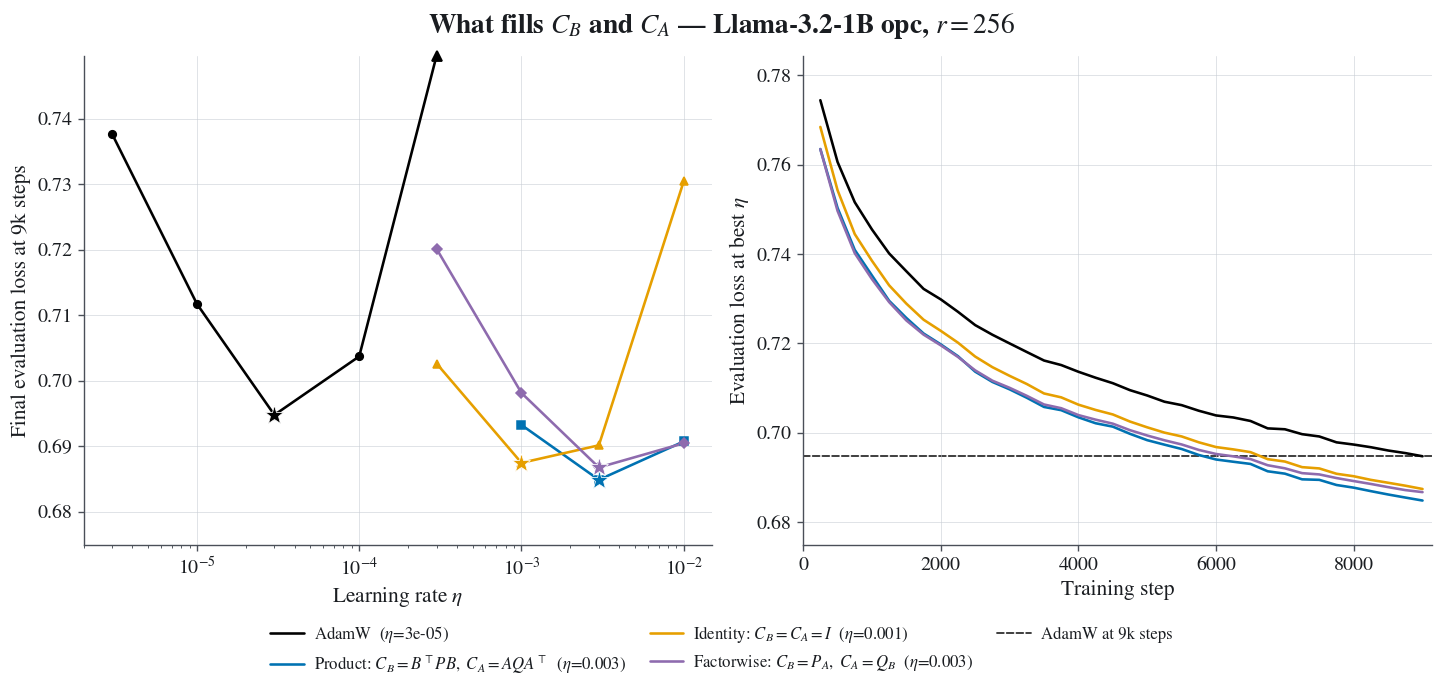

speedup vs AdamW (target 0.6948, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$      0.003   0.6848     1.55x    1.24x  3
  Factorwise: $C_B=P_A,\ C_A=Q_B$                 0.003   0.6867     1.44x    1.18x  4
  Identity: $C_B=C_A=I$                           0.001   0.6874     1.35x    1.16x  4
  AdamW                                           3e-05   0.6948     1.00x    1.00x  5
4 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.694754,0.009905,5.826258,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.00300,0.684849,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.00100,0.687435,0.002586,1.520991,1
3,"Factorwise: $C_B=P_A,\ C_A=Q_B$",0.00300,0.686731,0.001882,1.107285,1


In [91]:
P.precond_panel(256, data_key="opc")


### Figure 26. Qwen2.5-1.5B · OPC · r=256

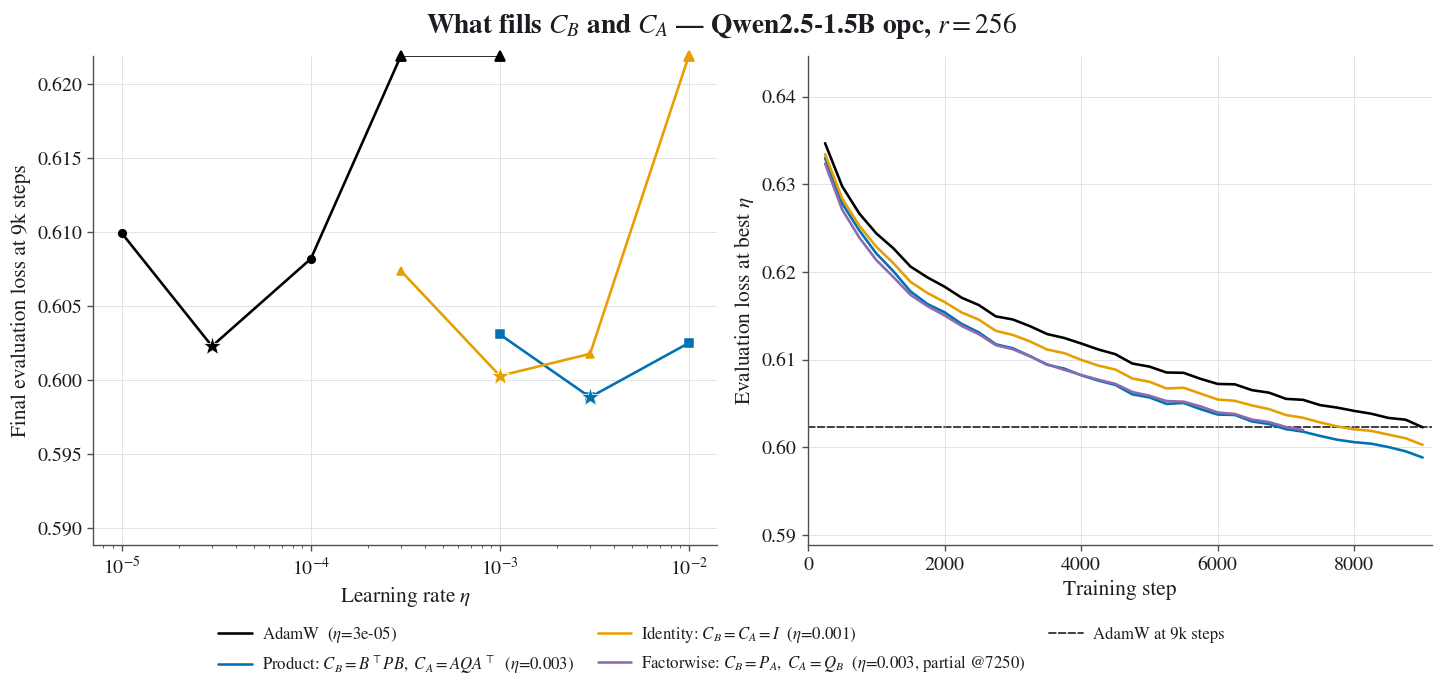

speedup vs AdamW (target 0.6023, horizon 9000)
  arm                                          best eta    final   speedup   lr-avg  n_lr
  Product: $C_B=B^\top P B,\ C_A=A Q A^\top$      0.003   0.5988     1.30x    1.08x  3
  Identity: $C_B=C_A=I$                           0.001   0.6003     1.15x    1.05x  4
  AdamW                                           3e-05   0.6023     1.00x    1.00x  5
8 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.00003,0.602292,0.003447,2.027497,1
1,"Product: $C_B=B^\top P B,\ C_A=A Q A^\top$",0.00300,0.598845,NaN,NaN,1
2,Identity: $C_B=C_A=I$,0.00100,0.600290,0.001445,0.849825,1


In [92]:
P.precond_panel(256, model="Qwen/Qwen2.5-1.5B", data_key="opc", model_label="Qwen2.5-1.5B")


### Figure 27. Freezing the $r\times r$ slots — Qwen2.5-1.5B openmath, $r=16$

Each frozen arm forks its own dynamic control at step 2000 and continues to
9000 with the $P_A$, $Q_B$ EMA writes stopped, so the two arms share identical
history up to the fork and differ only in whether those two matrices keep
updating.

**Plotted:** final eval loss vs learning rate and the best-lr trajectory for
the live and frozen arms.
**Why:** whether the $r\times r$ ESTIMATE earns its place or only its shape.
Shared history makes this paired, so noise up to step 2000 cancels; it is
still one seed per learning rate.

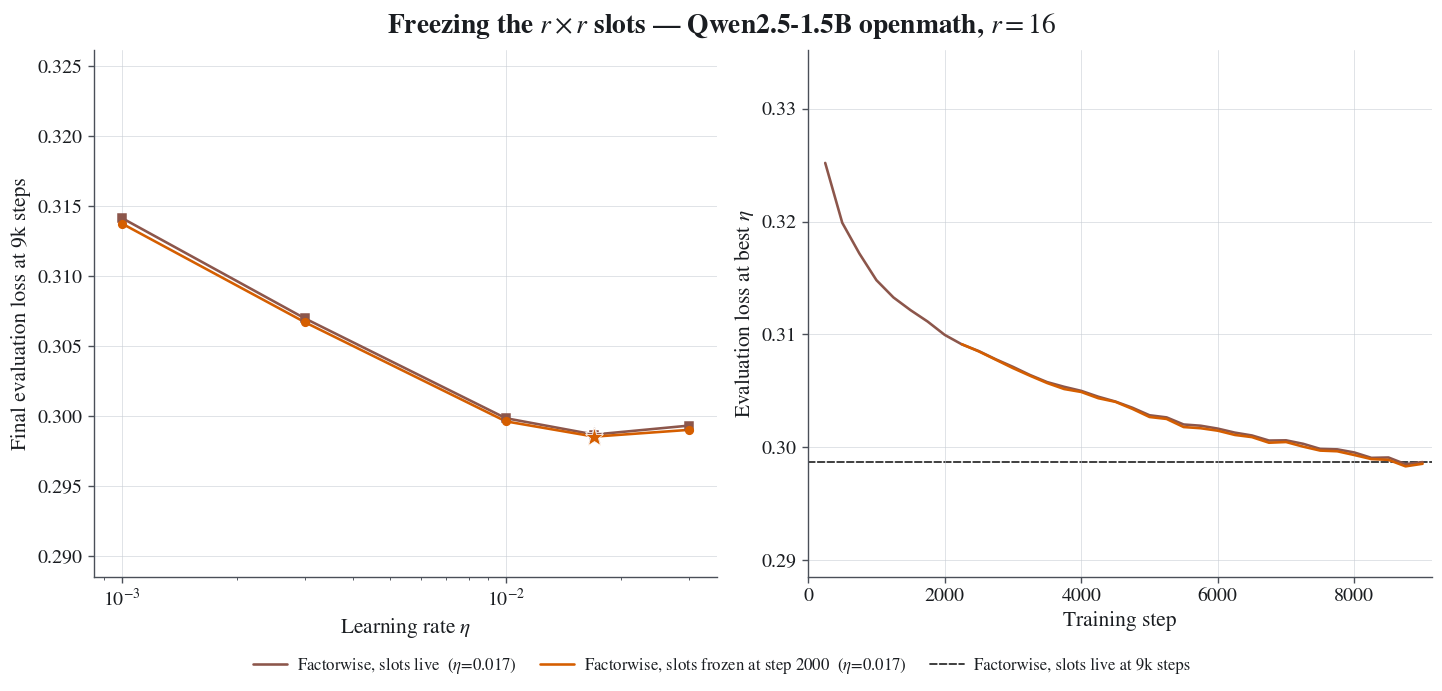

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,"Factorwise, slots live",0.017,0.298677,NaN,NaN,1
1,"Factorwise, slots frozen at step 2000",0.017,0.298528,-0.000149,-0.087433,1


In [99]:
P.factorwise_freeze_panel(16)

### Figure 28. Freezing the $r\times r$ slots — Qwen2.5-1.5B openmath, $r=256$

Each frozen arm forks its own dynamic control at step 2000 and continues to
9000 with the $P_A$, $Q_B$ EMA writes stopped, so the two arms share identical
history up to the fork and differ only in whether those two matrices keep
updating.

**Plotted:** final eval loss vs learning rate and the best-lr trajectory for
the live and frozen arms.
**Why:** whether the $r\times r$ ESTIMATE earns its place or only its shape.
Shared history makes this paired, so noise up to step 2000 cancels; it is
still one seed per learning rate.

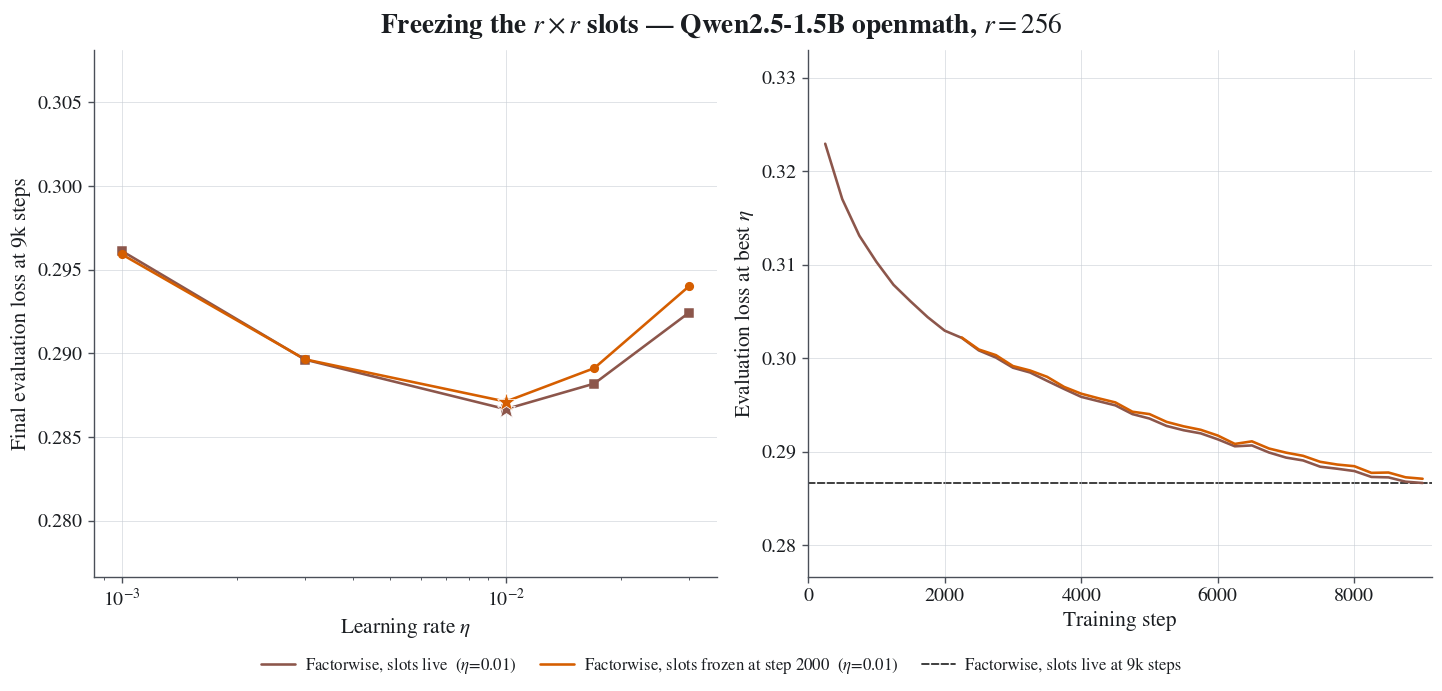

no speedup table: this panel declares no speed target.
5 run(s) excluded by 'precond' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,"Factorwise, slots live",0.01,0.286675,NaN,NaN,1
1,"Factorwise, slots frozen at step 2000",0.01,0.287126,0.000451,0.265411,1


In [100]:
P.factorwise_freeze_panel(256)

## Question 4 — How sensitive are the estimators to their memory horizon?

### Figure 29. Metric-slot β₂ sensitivity at r=16

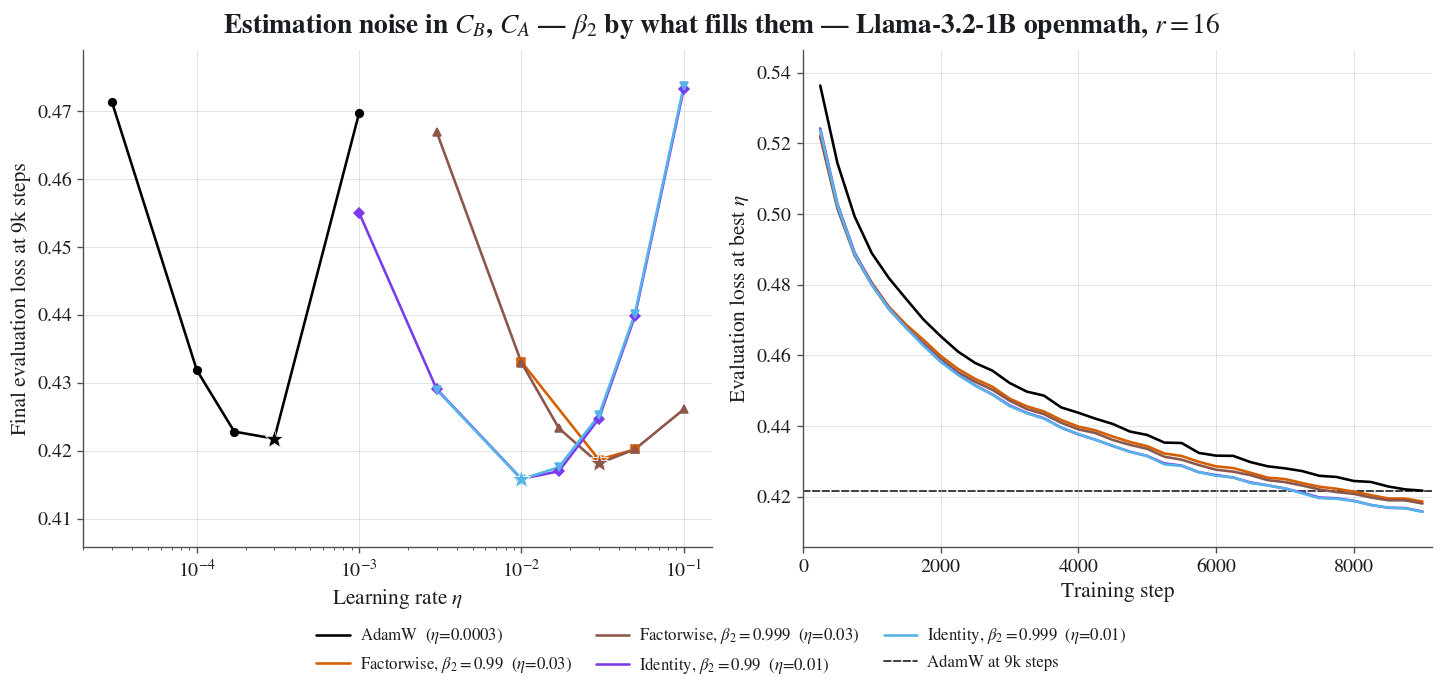

speedup vs AdamW (target 0.4218, horizon 9000)
  arm                           best eta    final   speedup   lr-avg  n_lr
  Identity, $\beta_2=0.999$         0.01   0.4158     1.27x    1.15x  6
  Identity, $\beta_2=0.99$          0.01   0.4158     1.26x    1.15x  7
  Factorwise, $\beta_2=0.999$       0.03   0.4181     1.18x    1.07x  6
  Factorwise, $\beta_2=0.99$        0.03   0.4187     1.14x    1.06x  3
  AdamW                           0.0003   0.4218     1.00x    1.00x  5
7 run(s) excluded by 'precond_beta2' semantic cohort: legacy commit predates the factorwise-slot fix


,variant,best_lr,final,delta,delta_sigma,n
0,AdamW,0.0003,0.421763,0.005922,3.483805,1
1,"Factorwise, $\beta_2=0.99$",0.0300,0.418685,0.002845,1.673279,1
2,"Factorwise, $\beta_2=0.999$",0.0300,0.418115,0.002275,1.338061,1
3,"Identity, $\beta_2=0.99$",0.0100,0.415841,NaN,NaN,2
4,"Identity, $\beta_2=0.999$",0.0100,0.415791,-0.000050,-0.029362,1


In [93]:
P.precond_beta2_panel(16)   # beta2 x precond at r=16, 9000 steps


### Figure 30. PoLoRA curvature β₂ sweep

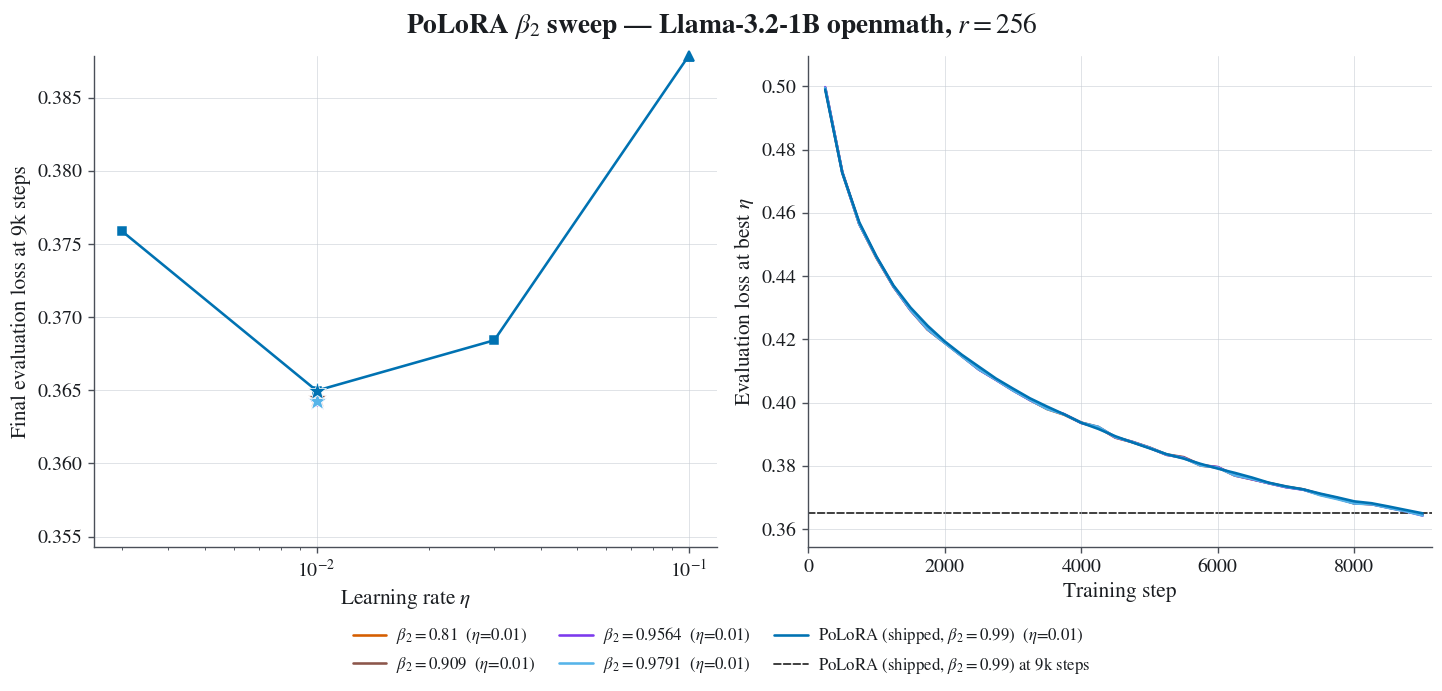

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,$\beta_2=0.81$,0.01,0.364447,-0.000524,-0.308196,1
1,$\beta_2=0.909$,0.01,0.364445,-0.000526,-0.309413,1
2,$\beta_2=0.9564$,0.01,0.364279,-0.000692,-0.406913,1
3,$\beta_2=0.9791$,0.01,0.364299,-0.000672,-0.395394,1
4,"PoLoRA (shipped, $\beta_2=0.99$)",0.01,0.364971,NaN,NaN,4


In [94]:
P.beta2_panel(256)


### Figure 31. AdamW β₂ control

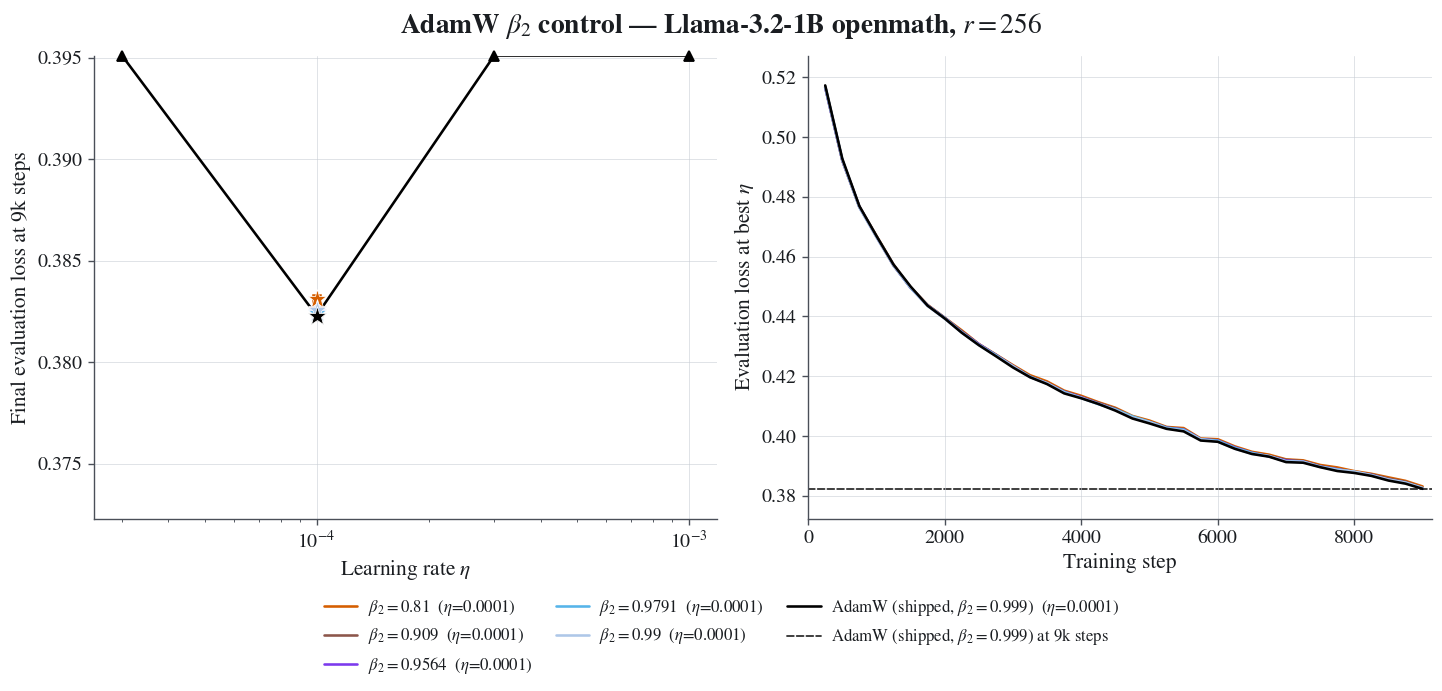

no speedup table: this panel declares no speed target.


,variant,best_lr,final,delta,delta_sigma,n
0,$\beta_2=0.81$,0.0001,0.383098,0.000798,0.469290,1
1,$\beta_2=0.909$,0.0001,0.382621,0.000320,0.188174,1
2,$\beta_2=0.9564$,0.0001,0.382463,0.000163,0.095758,1
3,$\beta_2=0.9791$,0.0001,0.382440,0.000140,0.082245,1
4,$\beta_2=0.99$,0.0001,0.382597,0.000296,0.174124,1
5,"AdamW (shipped, $\beta_2=0.999$)",0.0001,0.382301,NaN,NaN,1


In [95]:
P.adamw_beta2_panel(256)


## Question 5 — Do factor-geometry and magnitude diagnostics support the mechanism?

### Figure 32. Factor scale over training at r=256

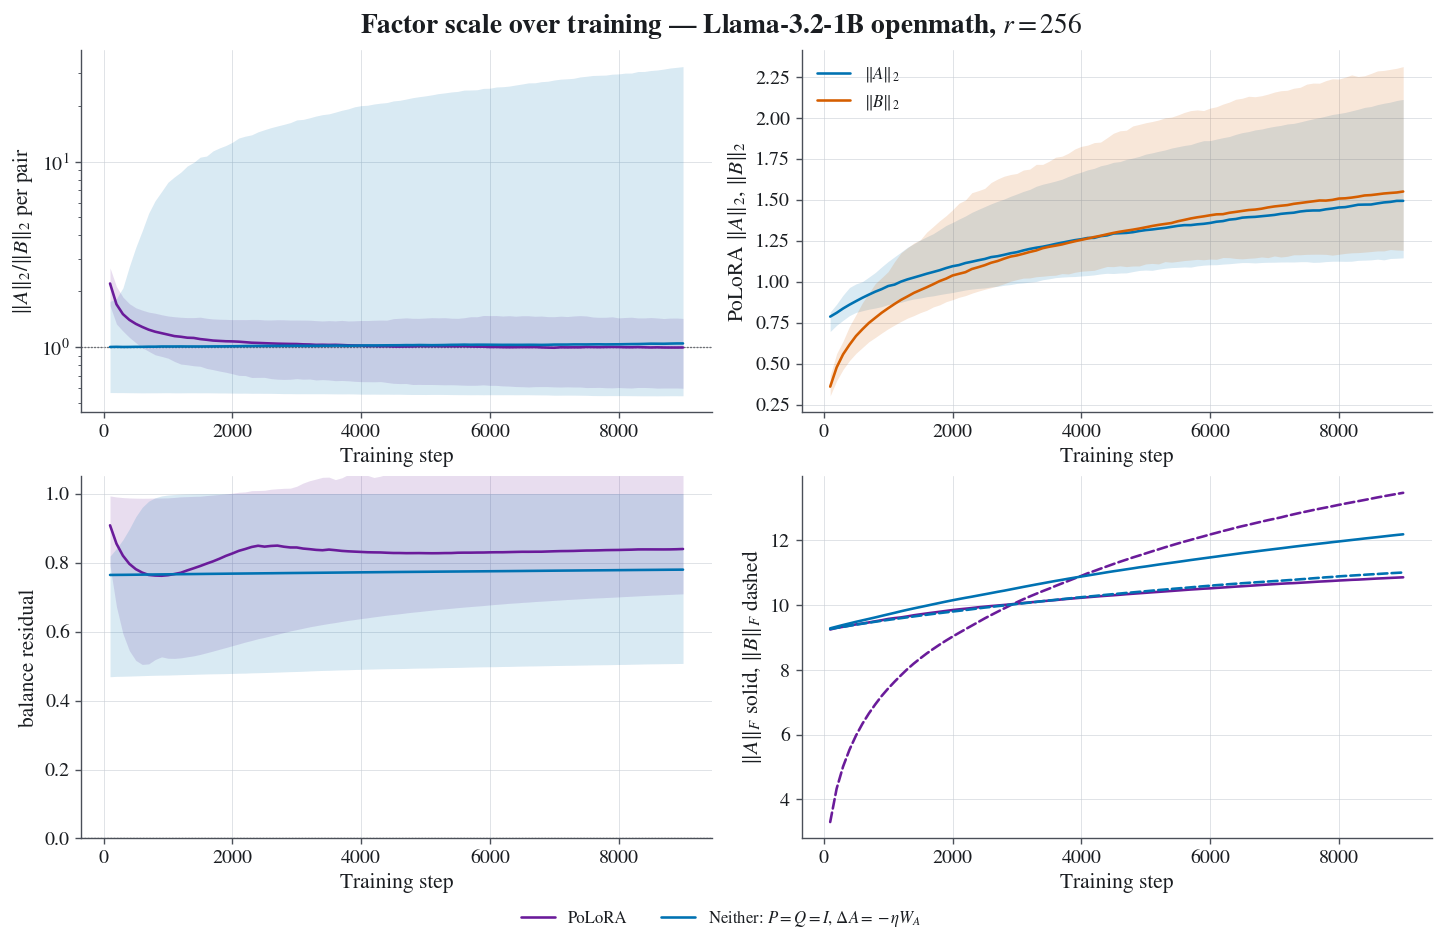

In [96]:
P.factor_rescaling_panel()

### Figure 33. Does factor rescaling weaken at r=16?

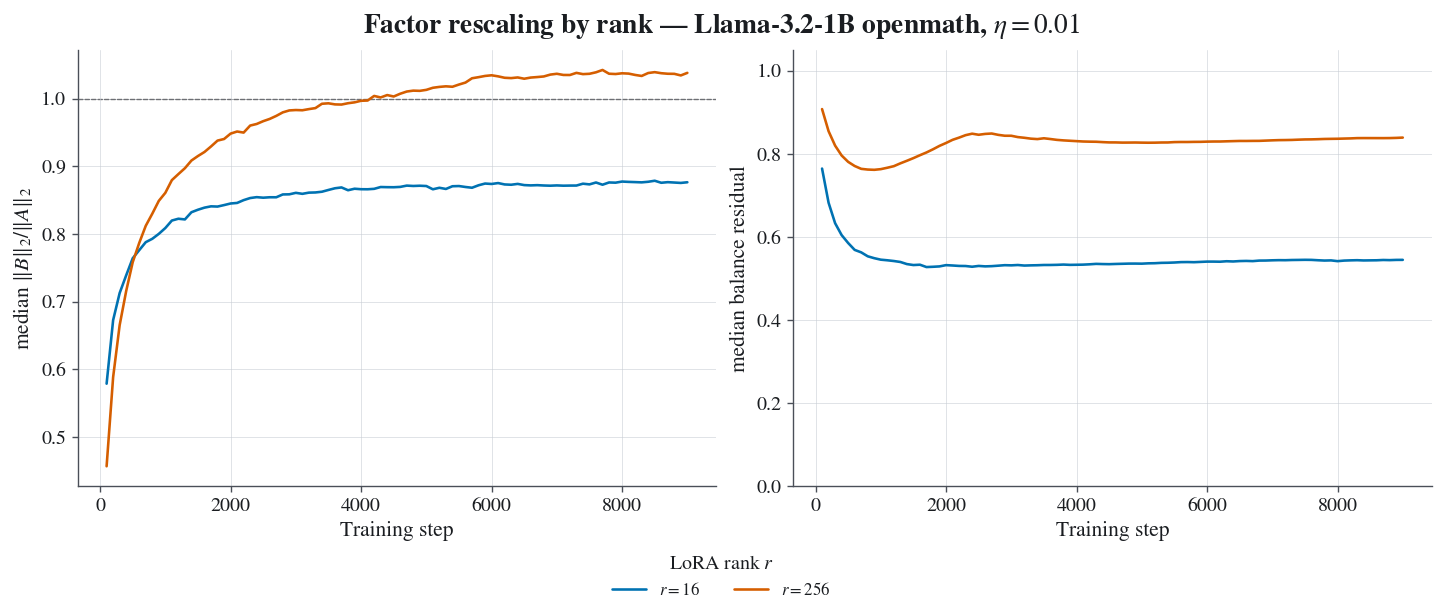

In [97]:
P.factor_rescaling_by_rank_panel()

### Figure 34. Does the solved magnitude rule track its bound?

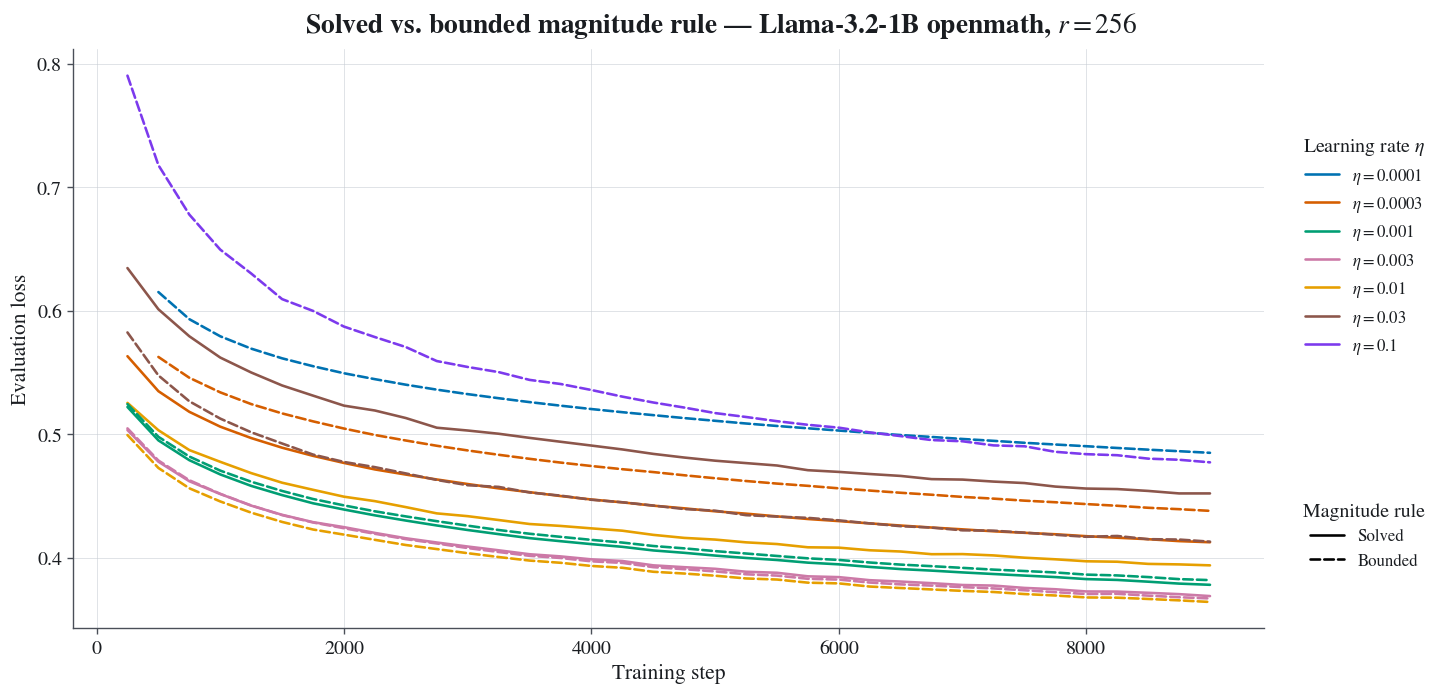

Solved: best eta=0.003 final=0.3692 (5 learning rates)
Bounded: best eta=0.01 final=0.3644 (7 learning rates)


In [98]:
P.magnitude_rule_tracking_panel()